**Full environment, dataset, and code setup**

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== CHANGE DIRECTORY (auto-detect Colab / Kaggle) =====
import os
BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "/content"
%cd $BASE
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!rm -rf $BASE/PGA_Unet2D
!git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git

# =========================================================
# DOWNLOAD DATASET ZIP FROM GOOGLE DRIVE
# =========================================================

!gdown --id 1GqI1l3I9QglI3XXL_rRAUTheSTIwh2c7 -O dataset_BTXRD.zip
# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -oq dataset_BTXRD.zip

# =========================================================
# INSPECT DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET INTO THE PROJECT
# =========================================================

!rm -rf PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_BTXRD
!mv dataset_BTXRD PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/

# =========================================================
# ENTER THE PROJECT DIRECTORY
# =========================================================

%cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown scipy

print("\nSETUP DONE!")

/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4327, done.
remote: Counting objects: 100% (564/564), done.
remote: Compressing objects: 100% (270/270), done.
remote: Total 4327 (delta 375), reused 422 (delta 293), pack-reused 3763 (from 2)
Receiving objects: 100% (4327/4327), 1.21 GiB | 35.37 MiB/s, done.
Resolving deltas: 100% (2589/2589), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1GqI1l3I9QglI3XXL_rRAUTheSTIwh2c7
From (redirected): https://drive.google.com/uc?id=1GqI1l3I9QglI3XXL_rRAUTheSTIwh2c7&confirm=t&uuid=6701d9ba-7bf7-46dd-892d-4975165fe5cc
To: /kaggle/working/dataset_BTXRD.zip
100%|███████████████████████████████████████| 1.71G/1.71G [00:07<00:00, 222MB/s]

DATASET STRUCTURE:
test  

**Train** (center_mixed x3/shift0.5, 80% shift / 20% zoom, QualityHead)

In [2]:
# =========================================================
# TRAIN - center_mixed (80% shift / 20% zoom) x3/shift0.5, QualityHead
# =========================================================
# Loss switch: set exactly one of these to 1 to compare against the baseline
# (both 0 = plain Dice + BCE, the default). Setting both to 1 raises a
# ValueError in train.py (they both replace dice_loss).
USE_SIZE_TVERSKY = 0   # size-conditioned Tversky: penalizes false positives more on small lesions
USE_FOCAL_DICE   = 0   # Focal Dice: amplifies gradient on the hardest samples

!PROMPT_DATASET_ROOT=dataset_BTXRD PROMPT_IMG_SIZE=512 \
 PROMPT_MODE=center_mixed PROMPT_SCALE_FACTOR=3.0 PROMPT_SHIFT_RATIO=0.5 PROMPT_MIXED_SHIFT_PROB=0.8 \
 USE_QUALITY_HEAD=1 LOSS_CONFIDENCE_WEIGHT=1.0 PROMPT_EPOCHS=150 PROMPT_SEED=22120196 \
 USE_SIZE_TVERSKY={USE_SIZE_TVERSKY} USE_FOCAL_DICE={USE_FOCAL_DICE} \
 python train.py

TrainPrompt: center_mixed | Device: cuda | EncoderPrompt: True | ImgSize: 512 | DatasetRoot: dataset_BTXRD | Seed: 22120196 | ScaleFactor: 3.0 | ShiftRatio: 0.5 | MixedShiftProb: 0.8 | QualityHead: ConfidenceLossWeight=1.0
Epoch 1/150 [Train]: 100%|███████| 470/470 [02:34<00:00,  3.05it/s, loss=1.4562]
🥇 [BEST] Epoch   1 | T_Loss: 1.4929 | [CENTER_] Dice:0.3023 IoU:0.1974 CBL:0.5916 | [CENTER_] Dice:0.2981 IoU:0.1936 CBL:0.5803 | LR:1.0e-04
Epoch 2/150 [Train]: 100%|███████| 470/470 [02:33<00:00,  3.07it/s, loss=1.2927]
🥇 [BEST] Epoch   2 | T_Loss: 1.3557 | [CENTER_] Dice:0.3940 IoU:0.2632 CBL:0.7131 | [CENTER_] Dice:0.3743 IoU:0.2514 CBL:0.6572 | LR:1.0e-04
Epoch 3/150 [Train]: 100%|███████| 470/470 [02:33<00:00,  3.07it/s, loss=1.1128]
🥇 [BEST] Epoch   3 | T_Loss: 1.2676 | [CENTER_] Dice:0.4400 IoU:0.3049 CBL:0.7315 | [CENTER_] Dice:0.4224 IoU:0.2883 CBL:0.7007 | LR:1.0e-04
Epoch 4/150 [Train]: 100%|███████| 470/470 [02:33<00:00,  3.06it/s, loss=1.1623]
🥇 [BEST] Epoch   4 | T_Loss: 1

## Test - two-scenario evaluation (center_zoom / center_shift) + no-GT confidence + sample visualization
Reports the six metrics under both scenarios, the model's own no-GT confidence (CAD prompt-confidence gate + QualityHead), and two 10-sample visualization grids, one per scenario (each sample's Dice/confidence/quality shown next to it).

Model loaded from: checkpoints/pga_unet_center_mixed_x3_shift05_qhead_512_best.pth  (loss = baseline_dice)

  TWO-SCENARIO EVALUATION (image-level merged)  |  encoder_prompt = ON  |  loss = baseline_dice
  [100% Zoom (center_zoom)]  187 images (214 polygons), completed.
  [100% Shift (center_shift)]  187 images (214 polygons), completed.

Scenario                   Dice↑    IoU↑    Pre↑    Rec↑  HD95px↓   HD95n↓    CBL↑ PromptConf  Quality  N_img  N_smp
-----------------------------------------------------------------------------------------------------------------
100% Zoom (center_zoom)   0.7698  0.6461  0.7429  0.8418    22.45 0.031001  0.9089     0.9078   0.7576    187    214
100% Shift (center_shift)  0.7571  0.6316  0.7470  0.8151    24.56 0.033916  0.8992     0.9075   0.7568    187    214

Saved CSV: results/pga_baseline_dice_512.csv


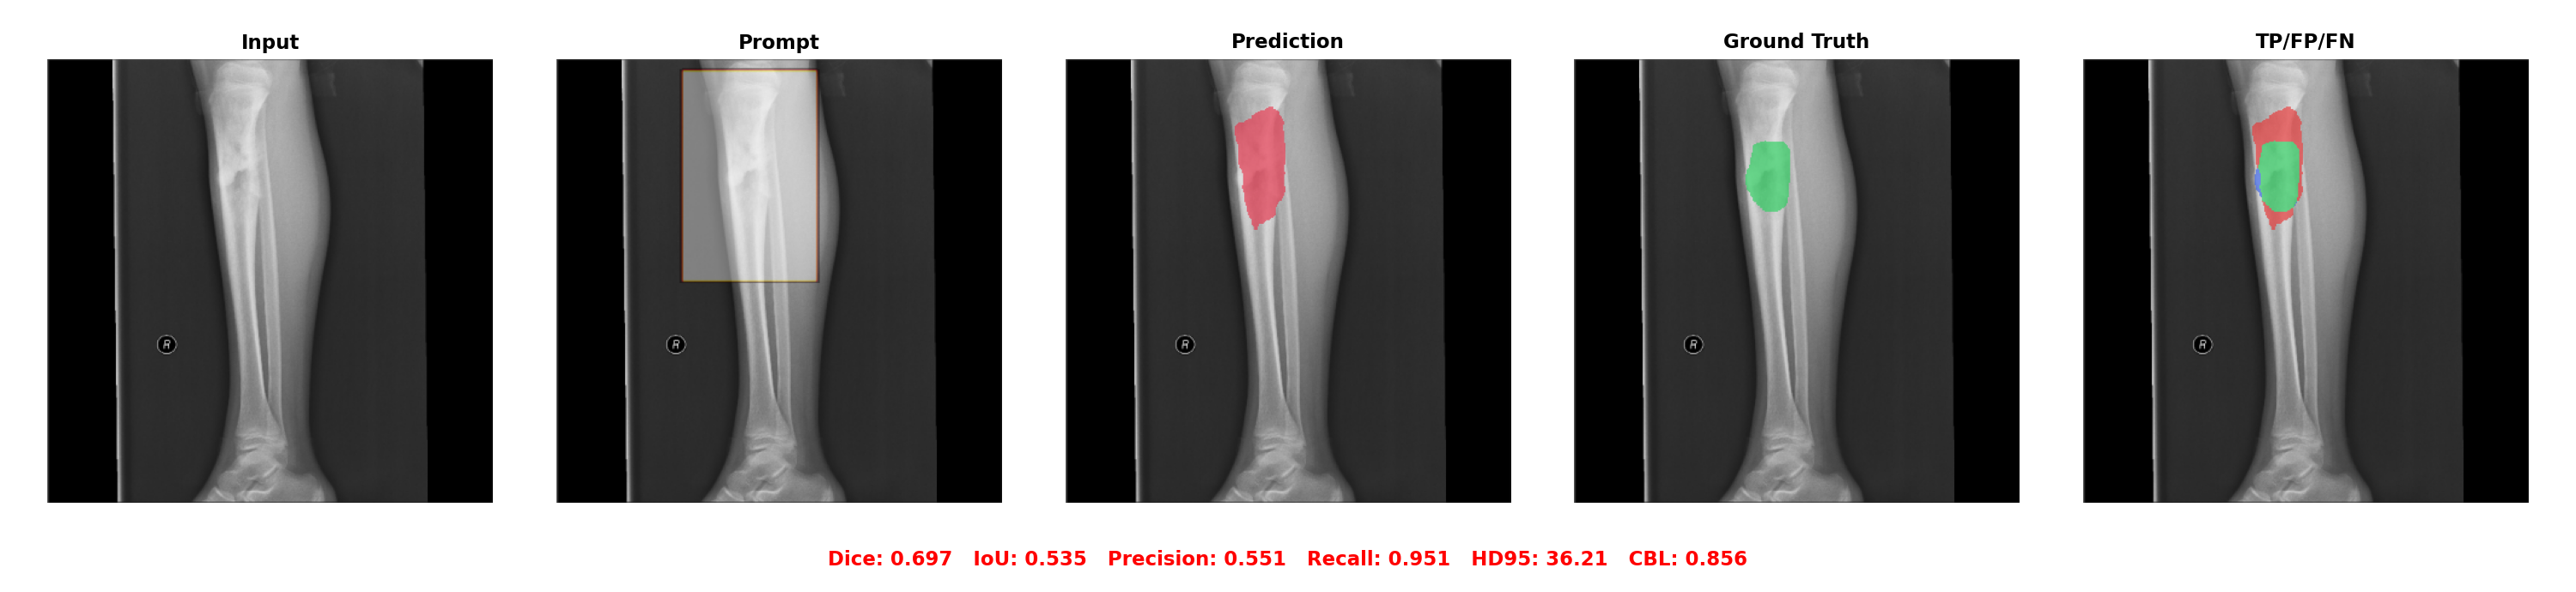

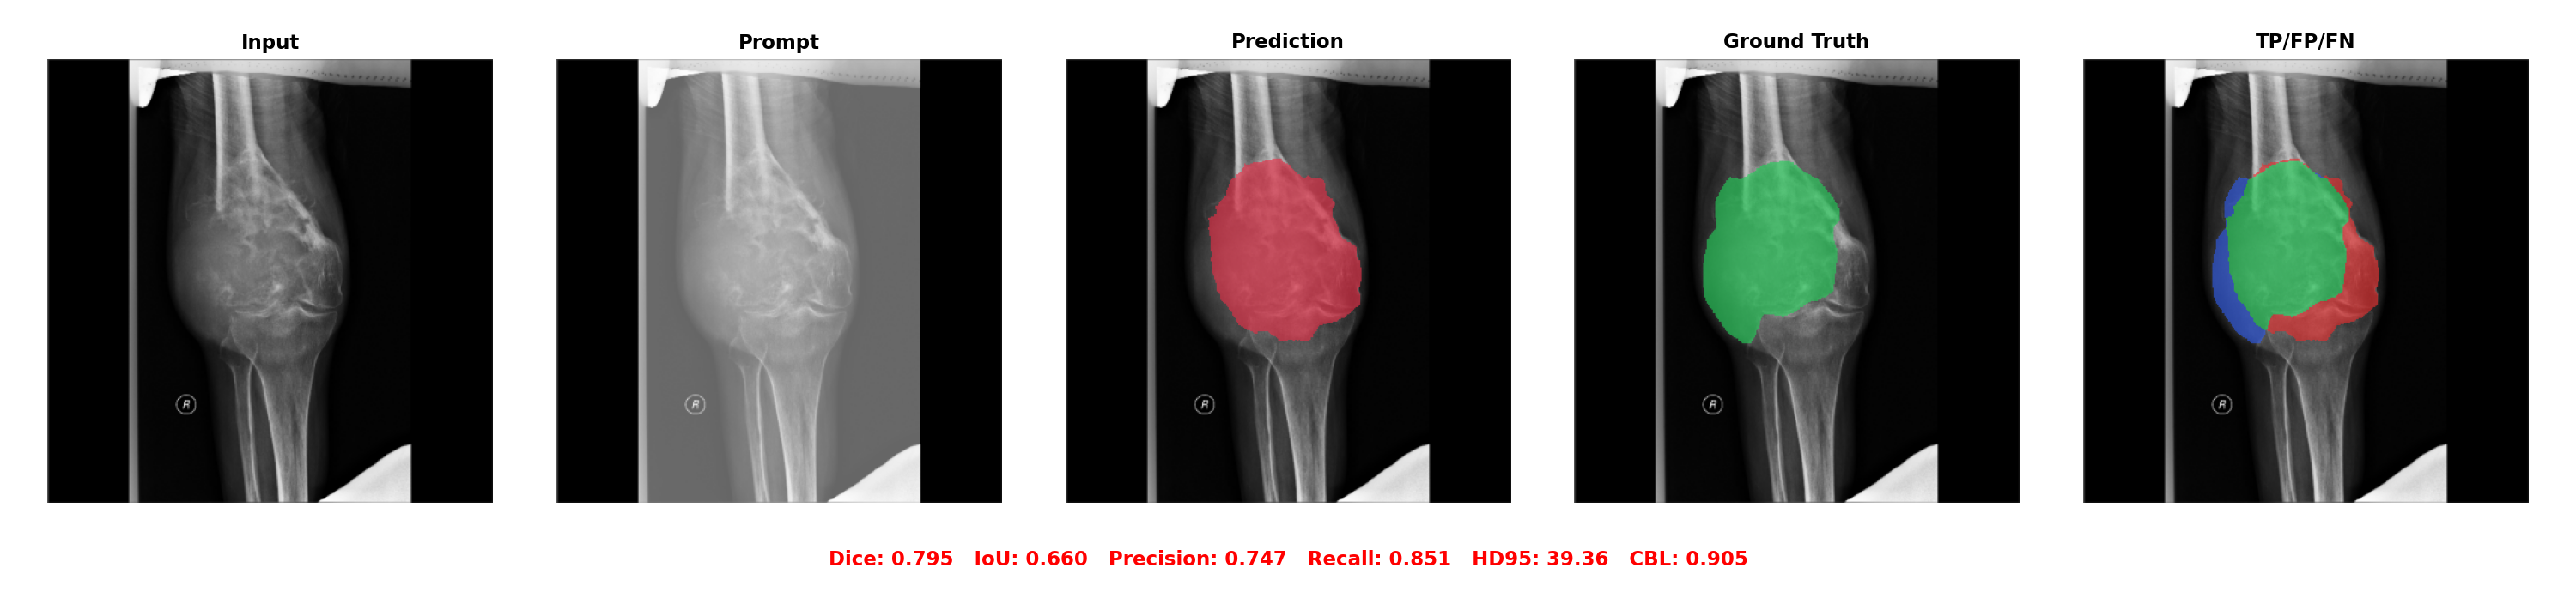

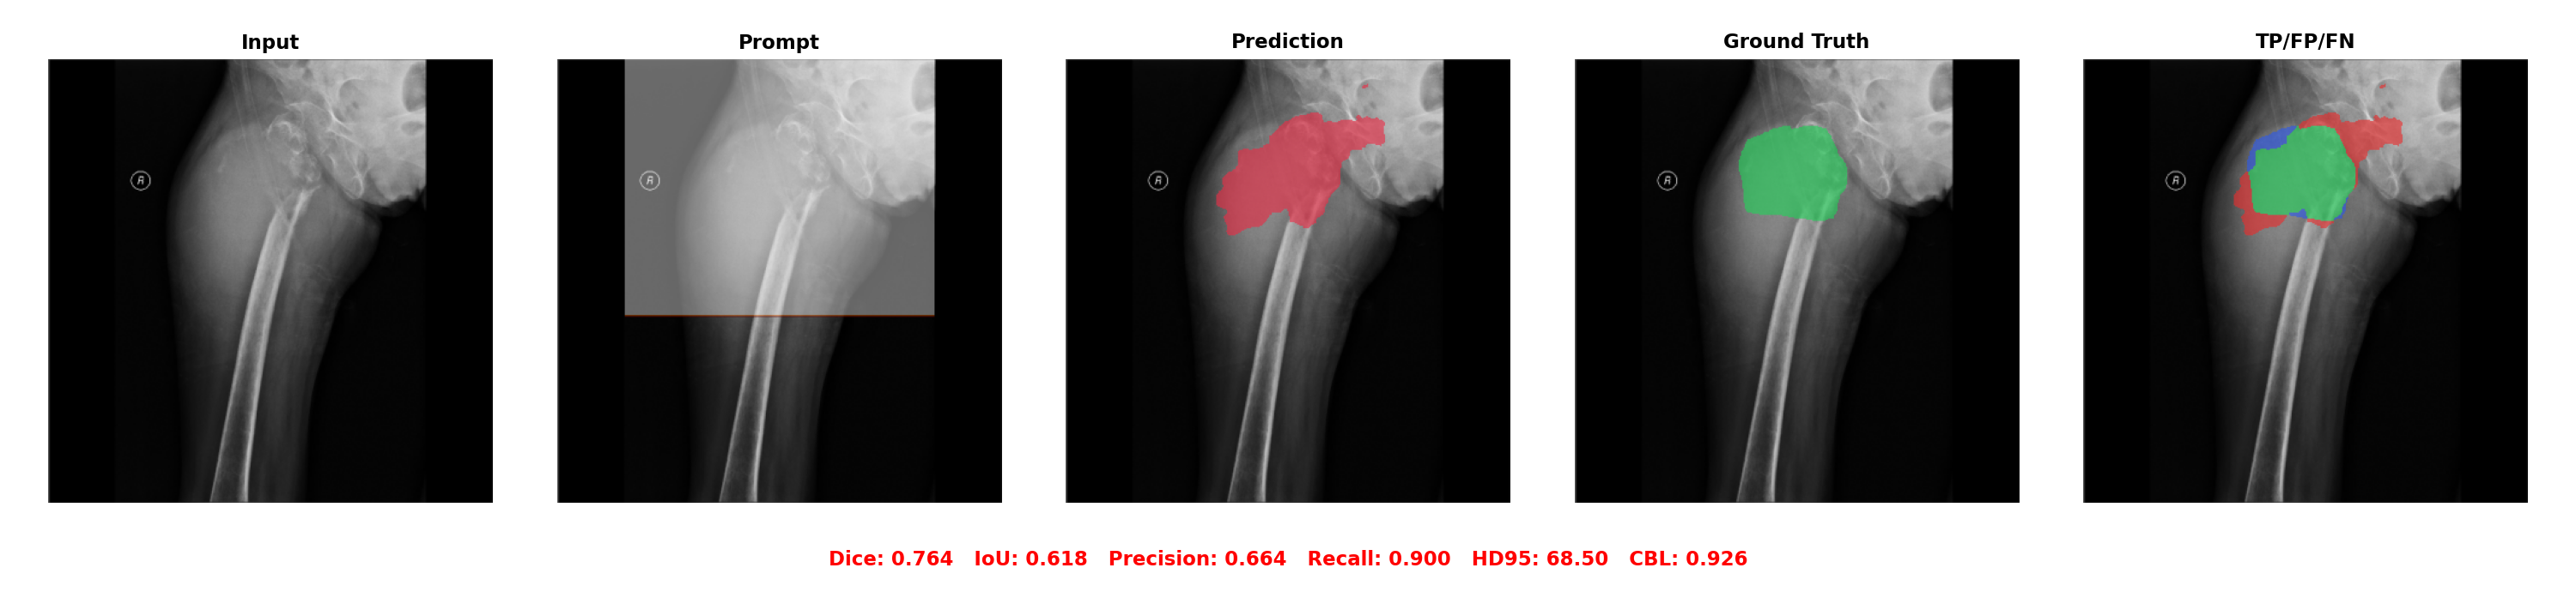

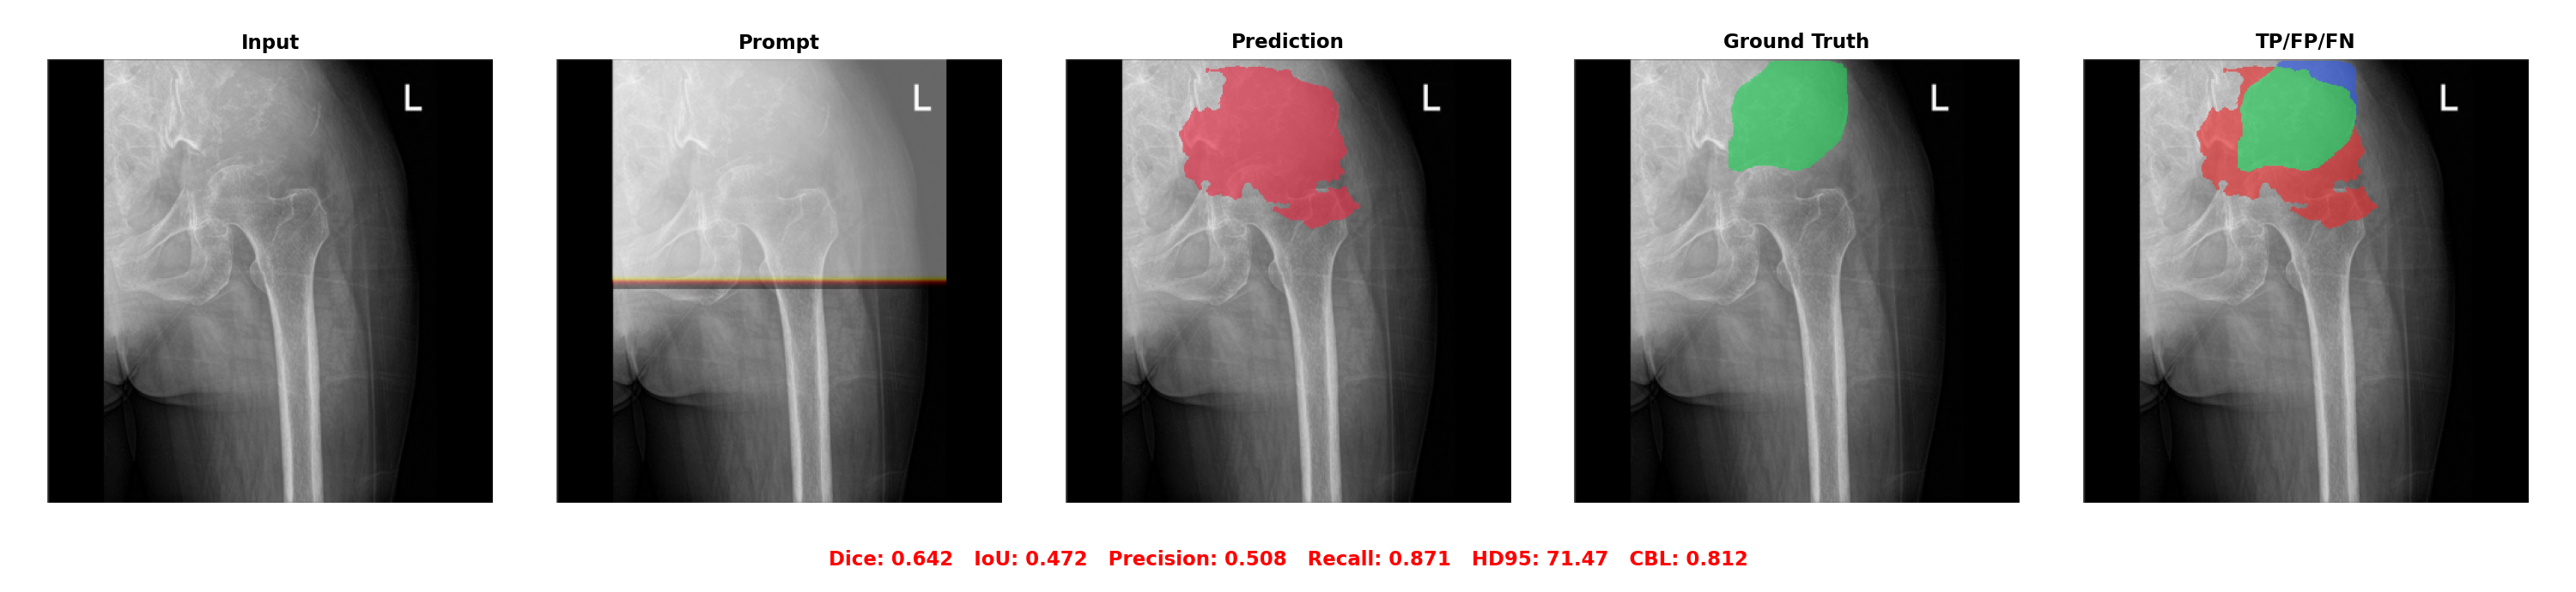

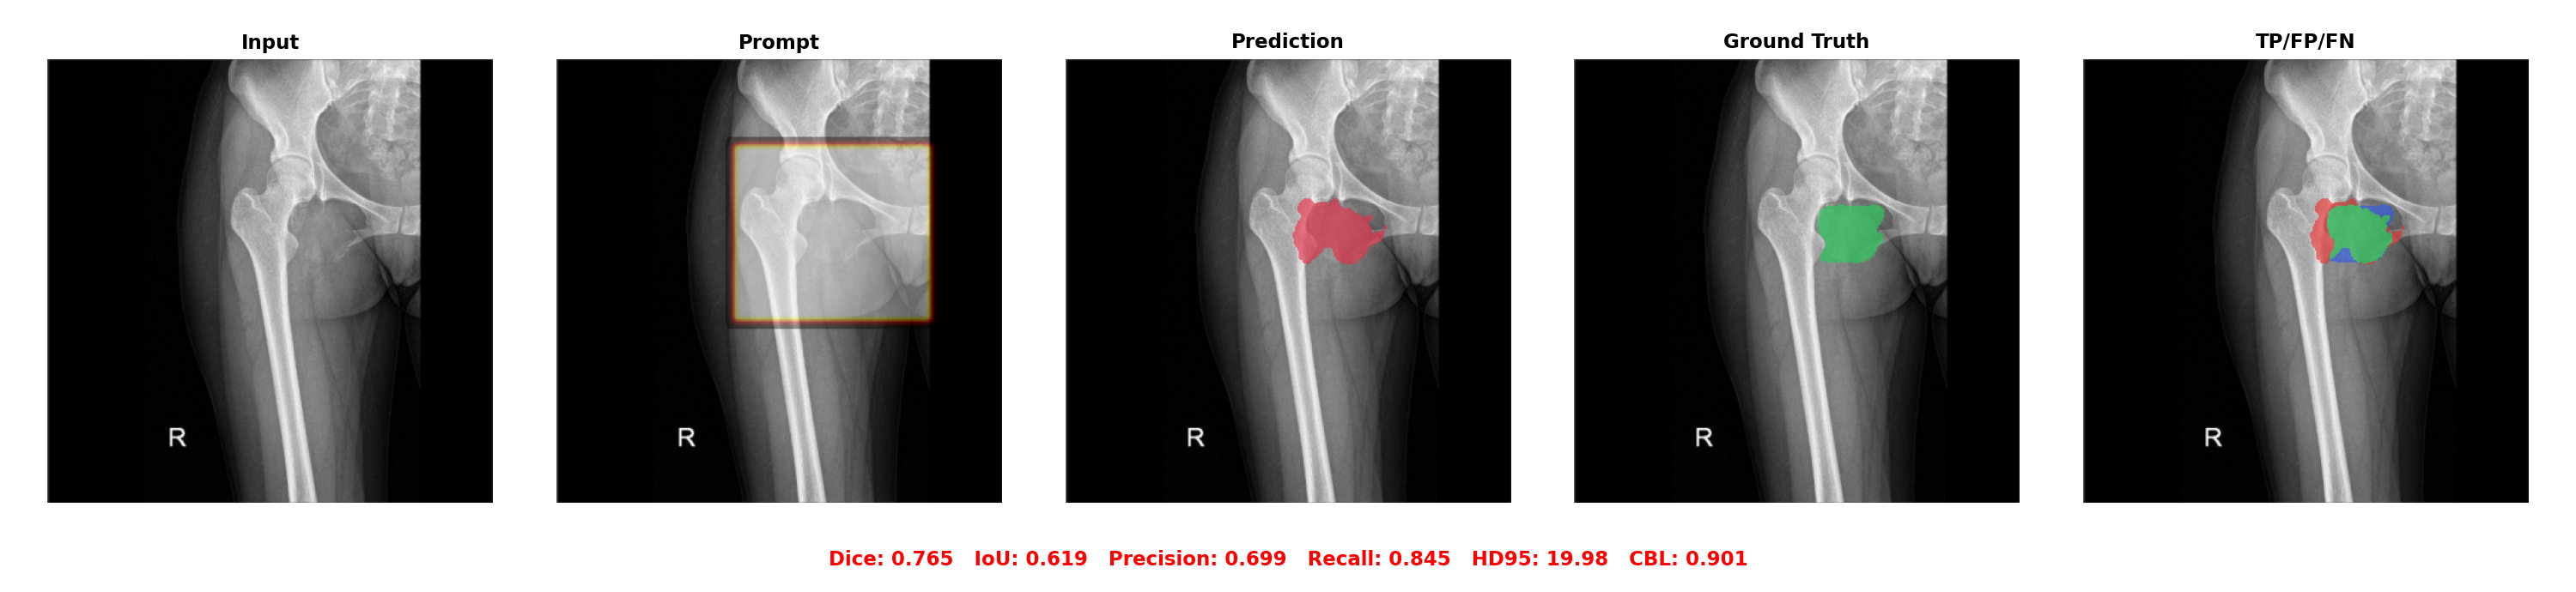

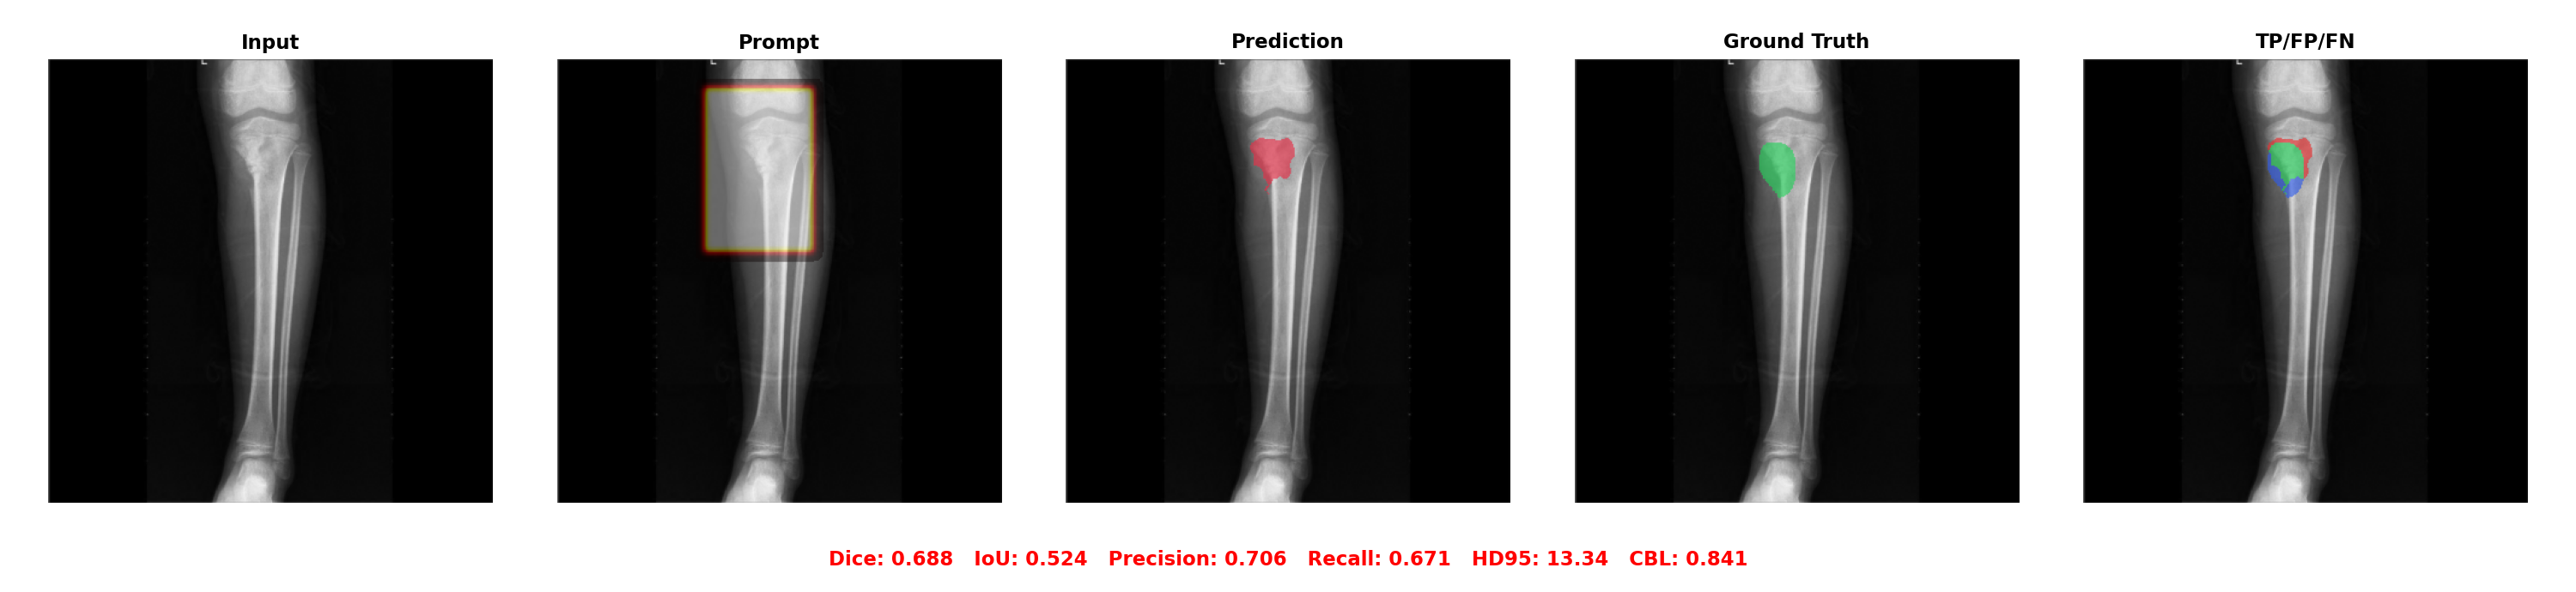

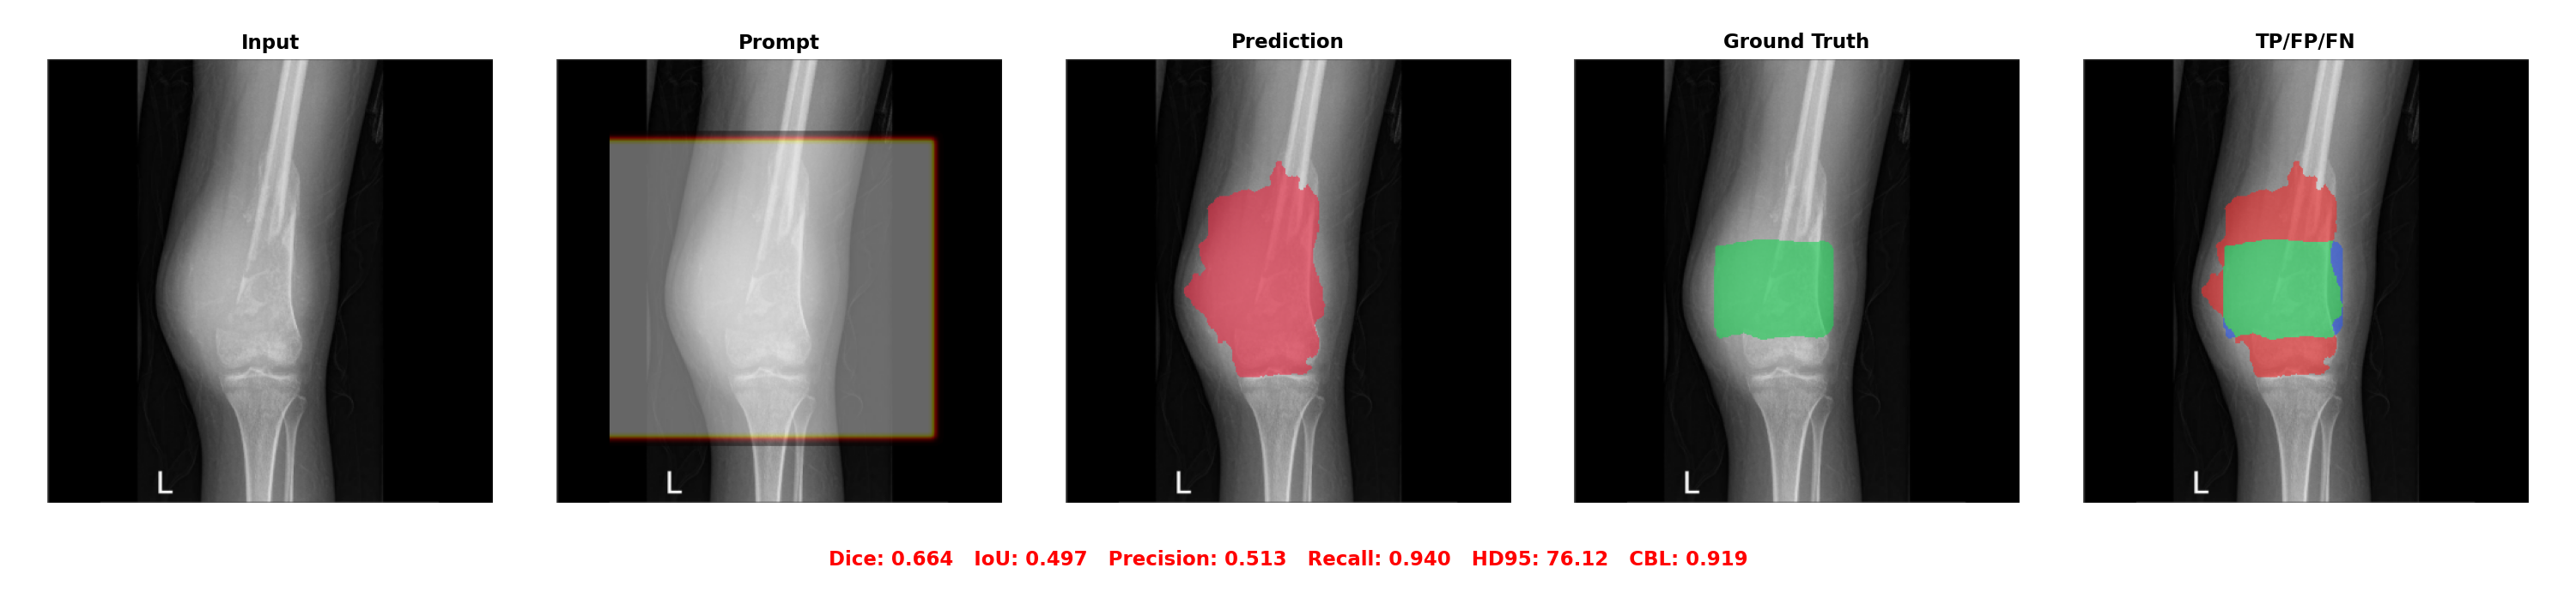

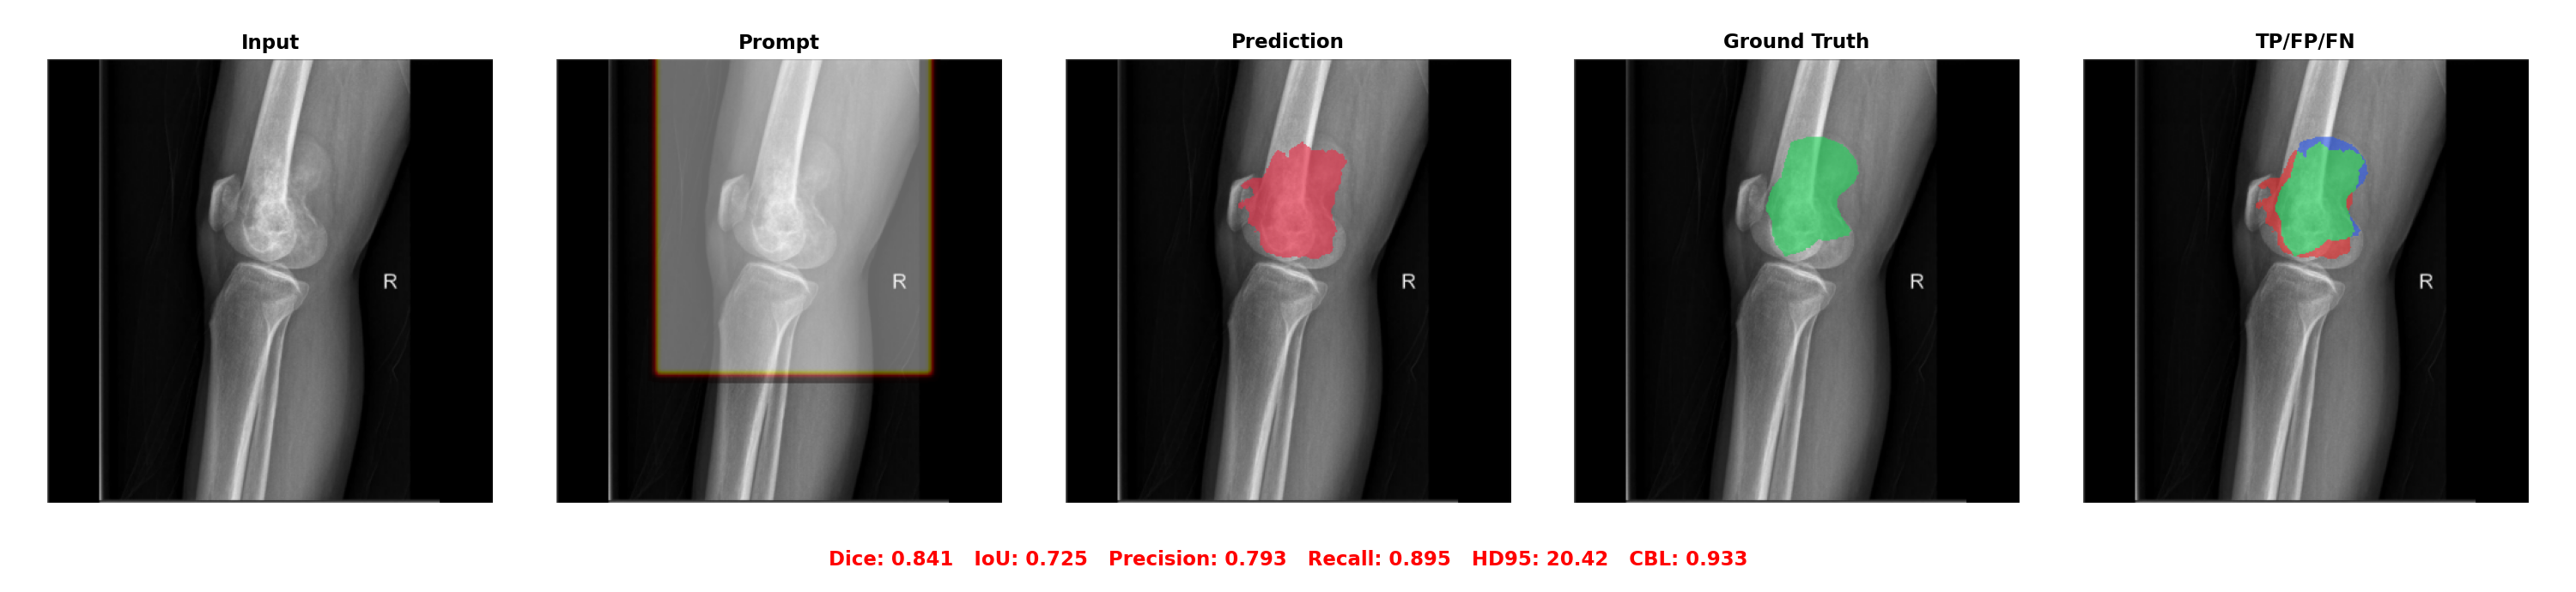

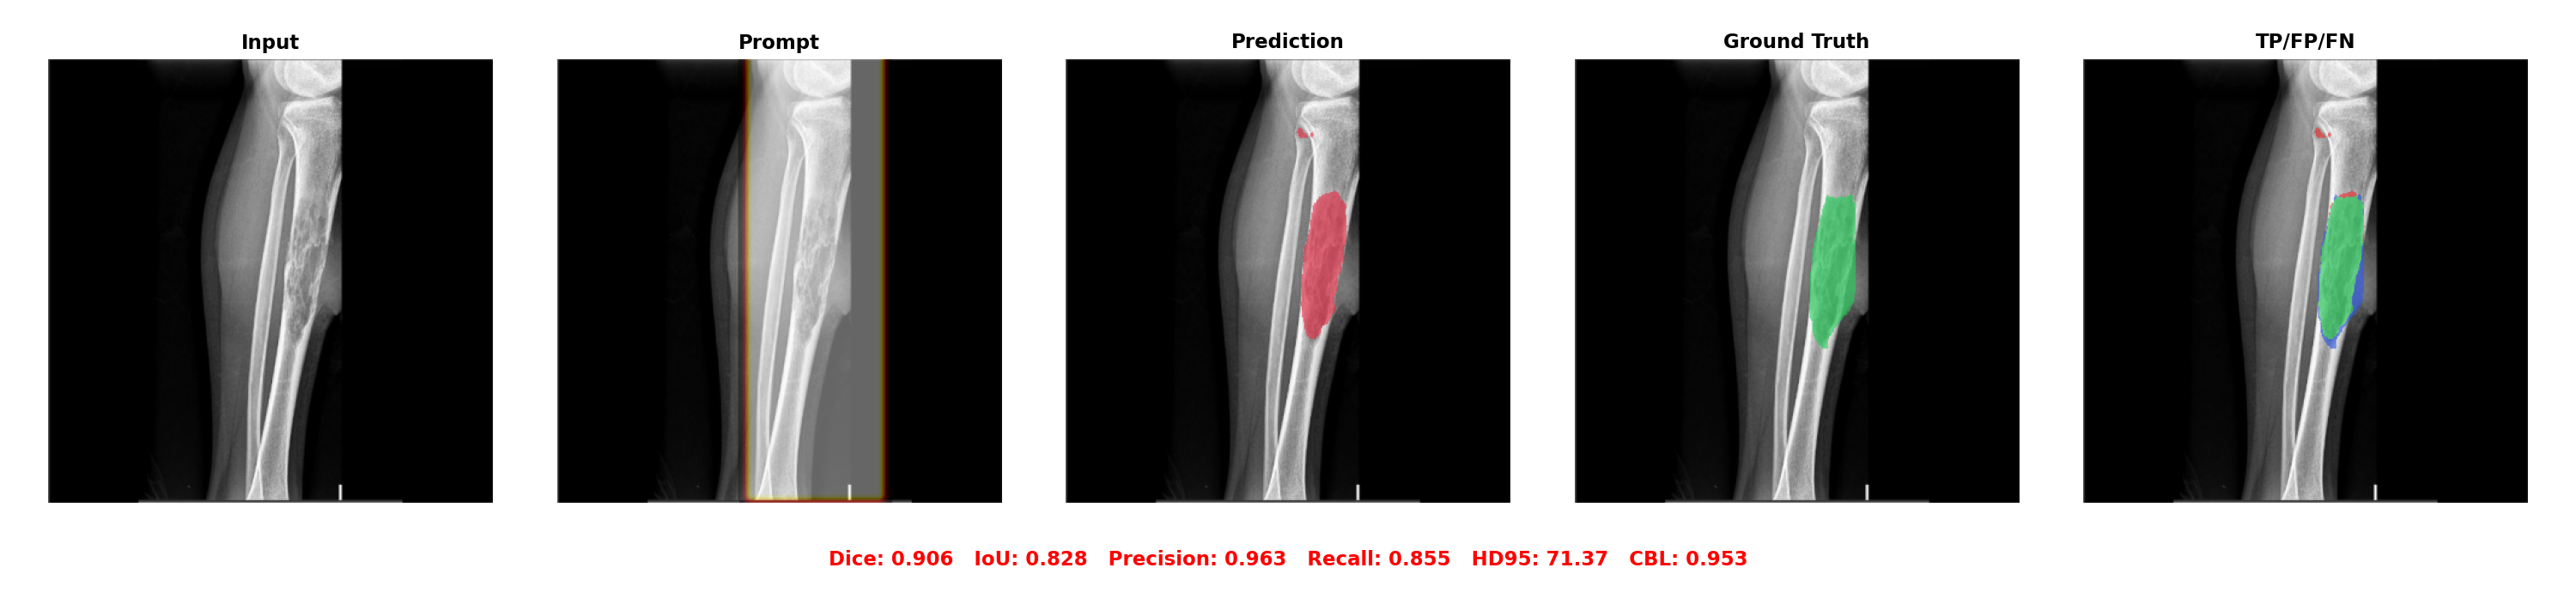

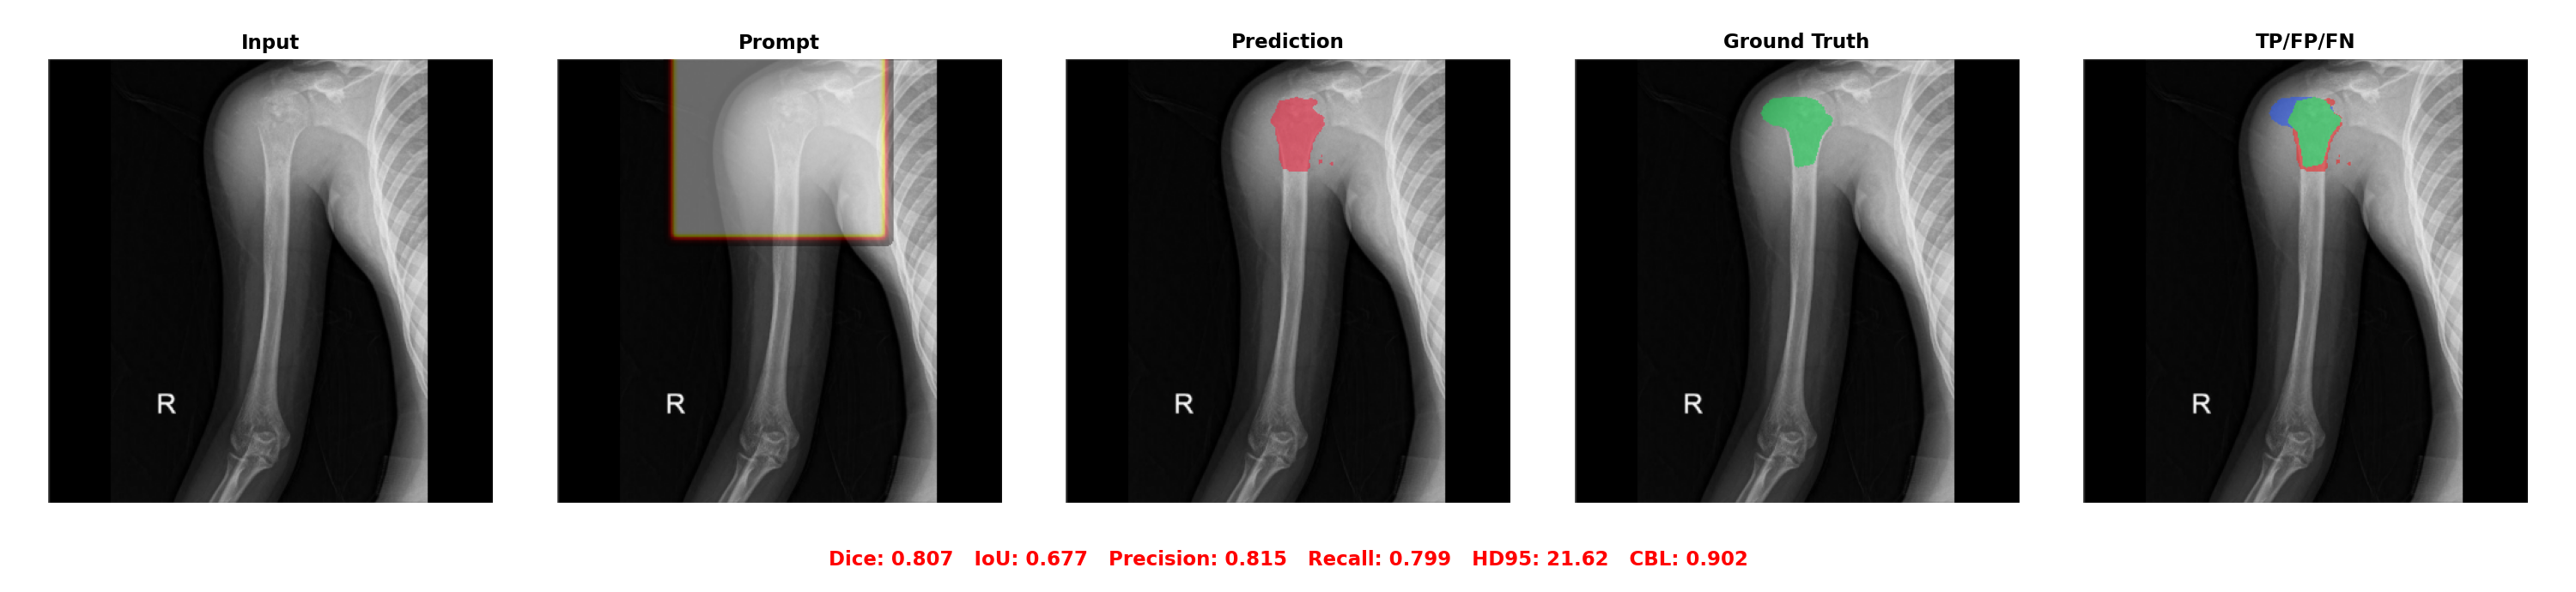

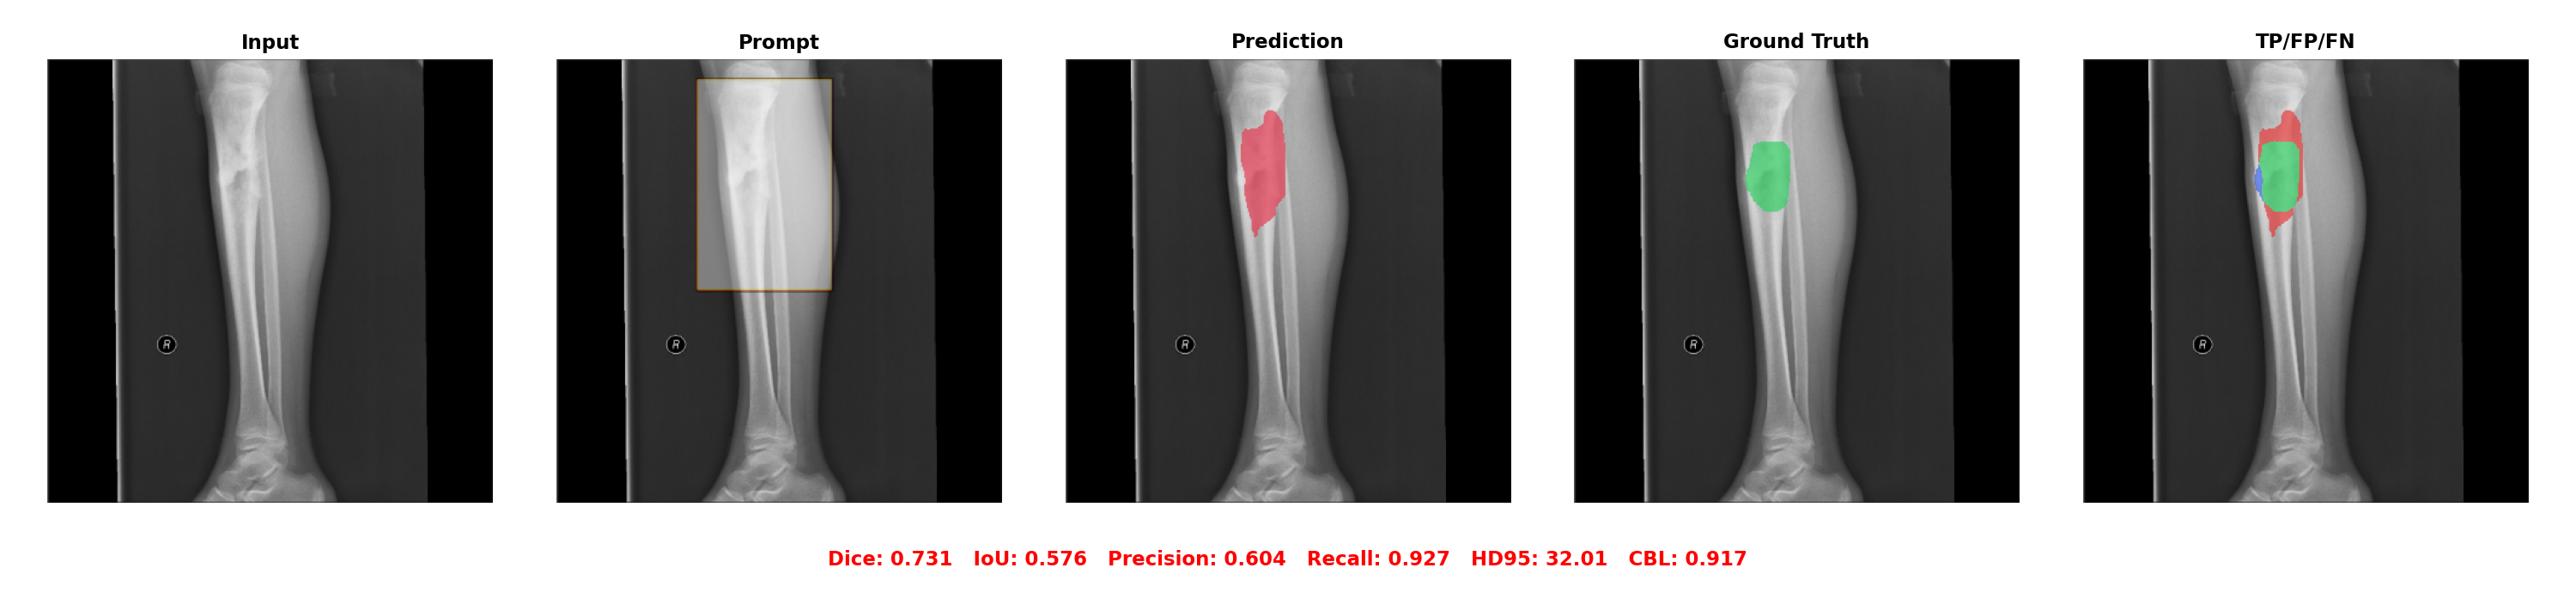

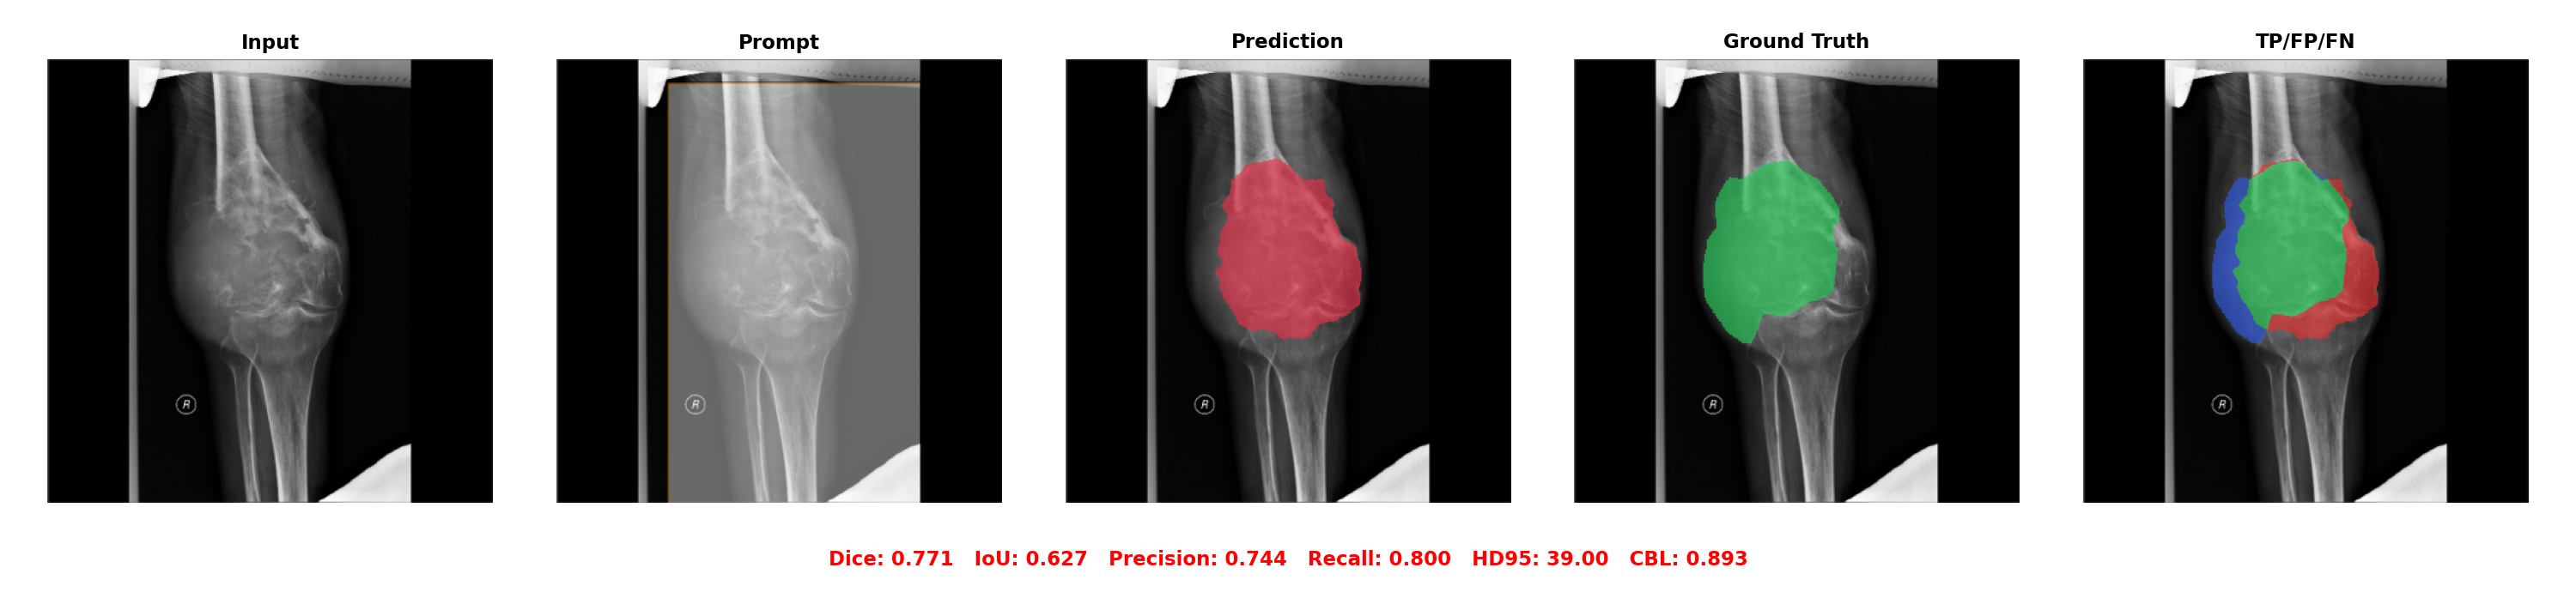

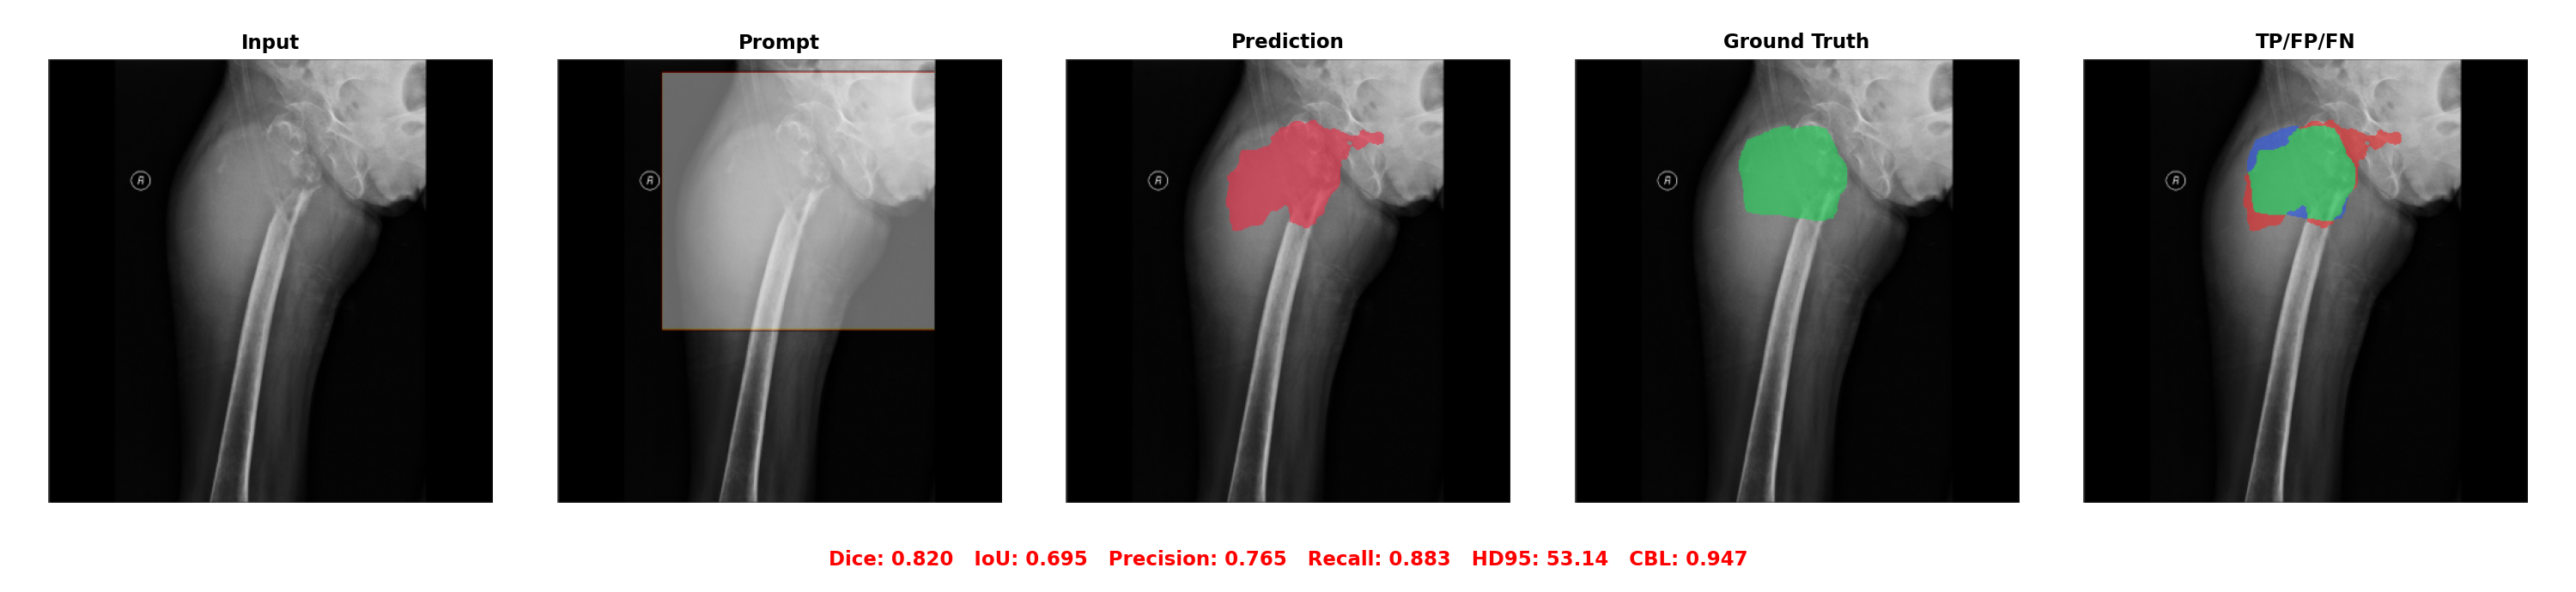

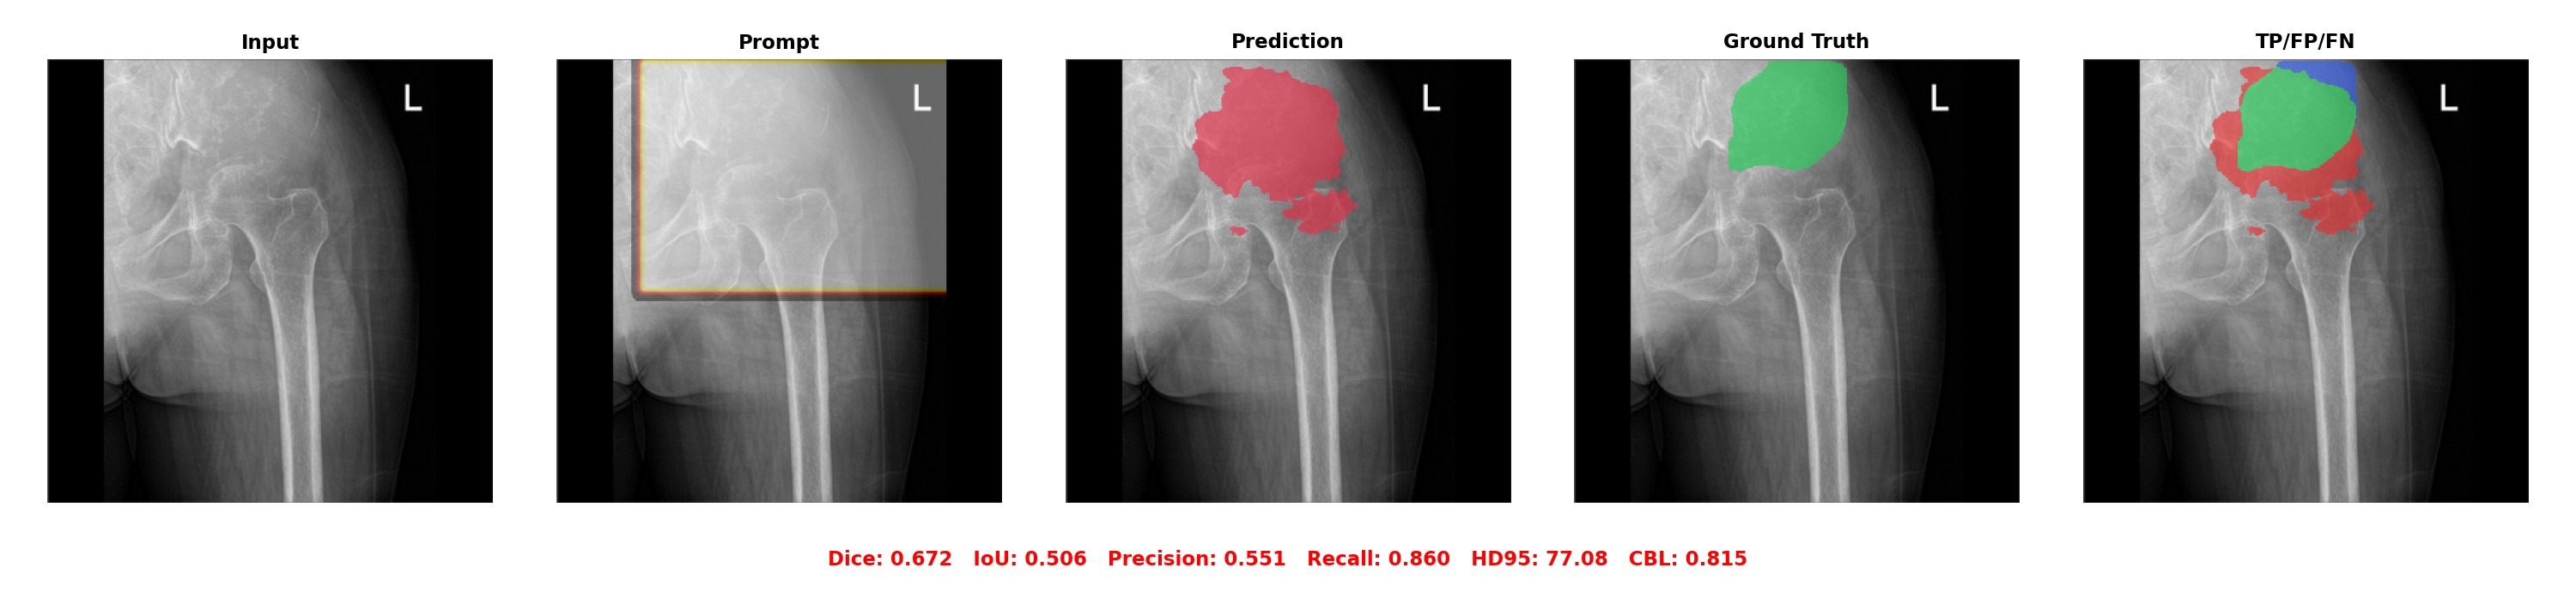

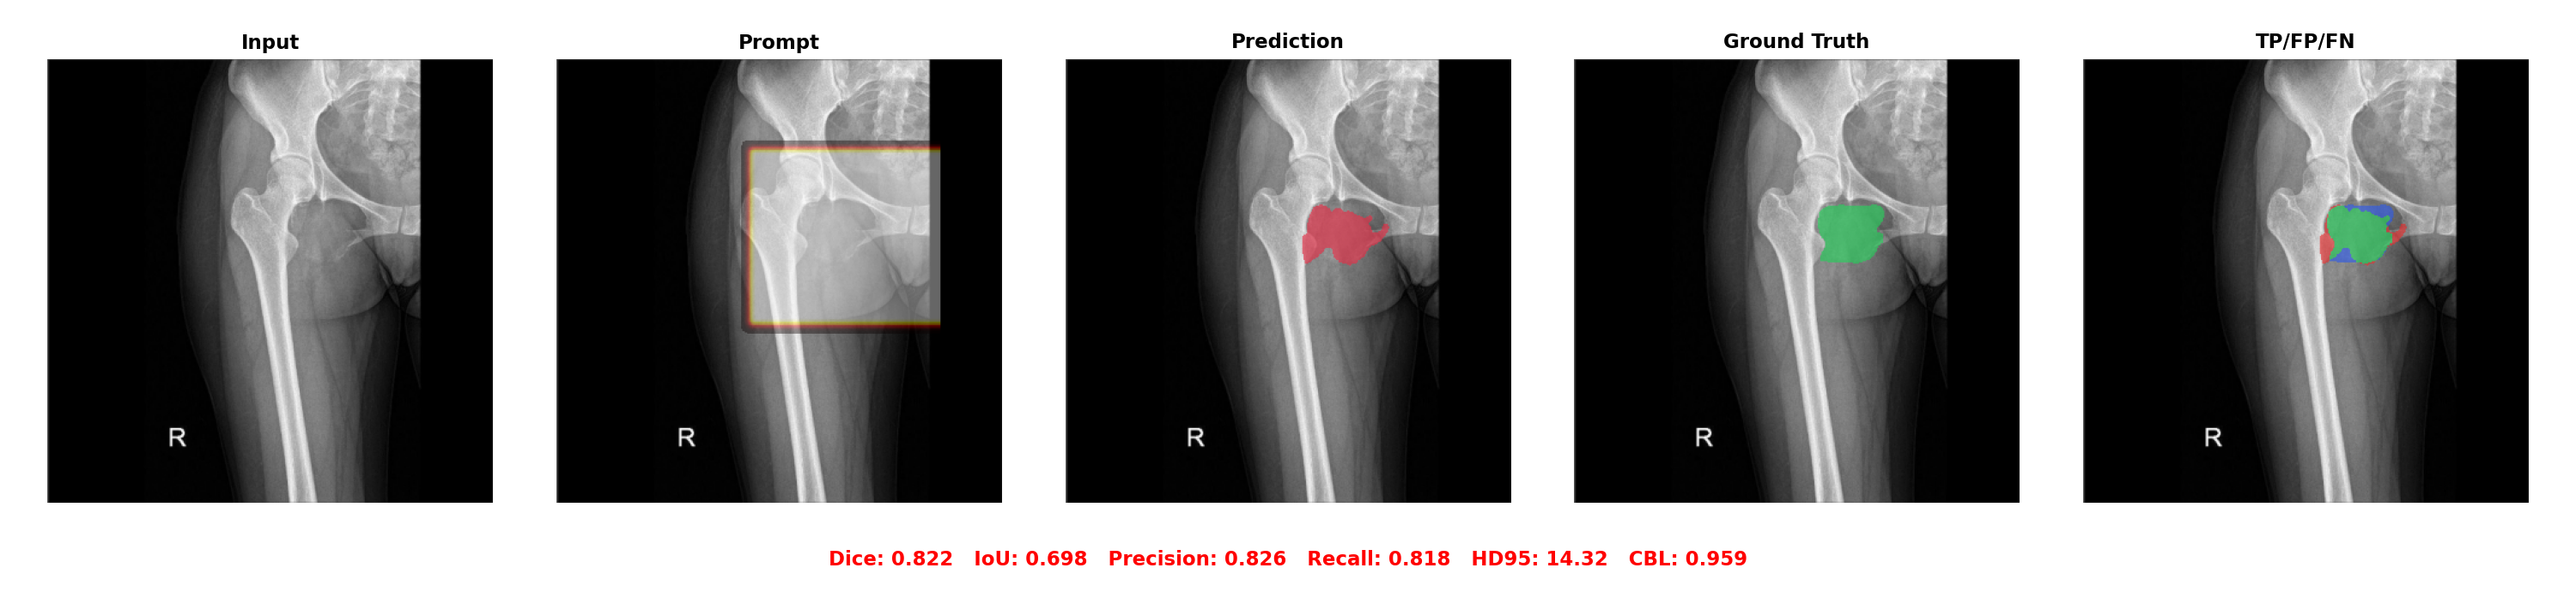

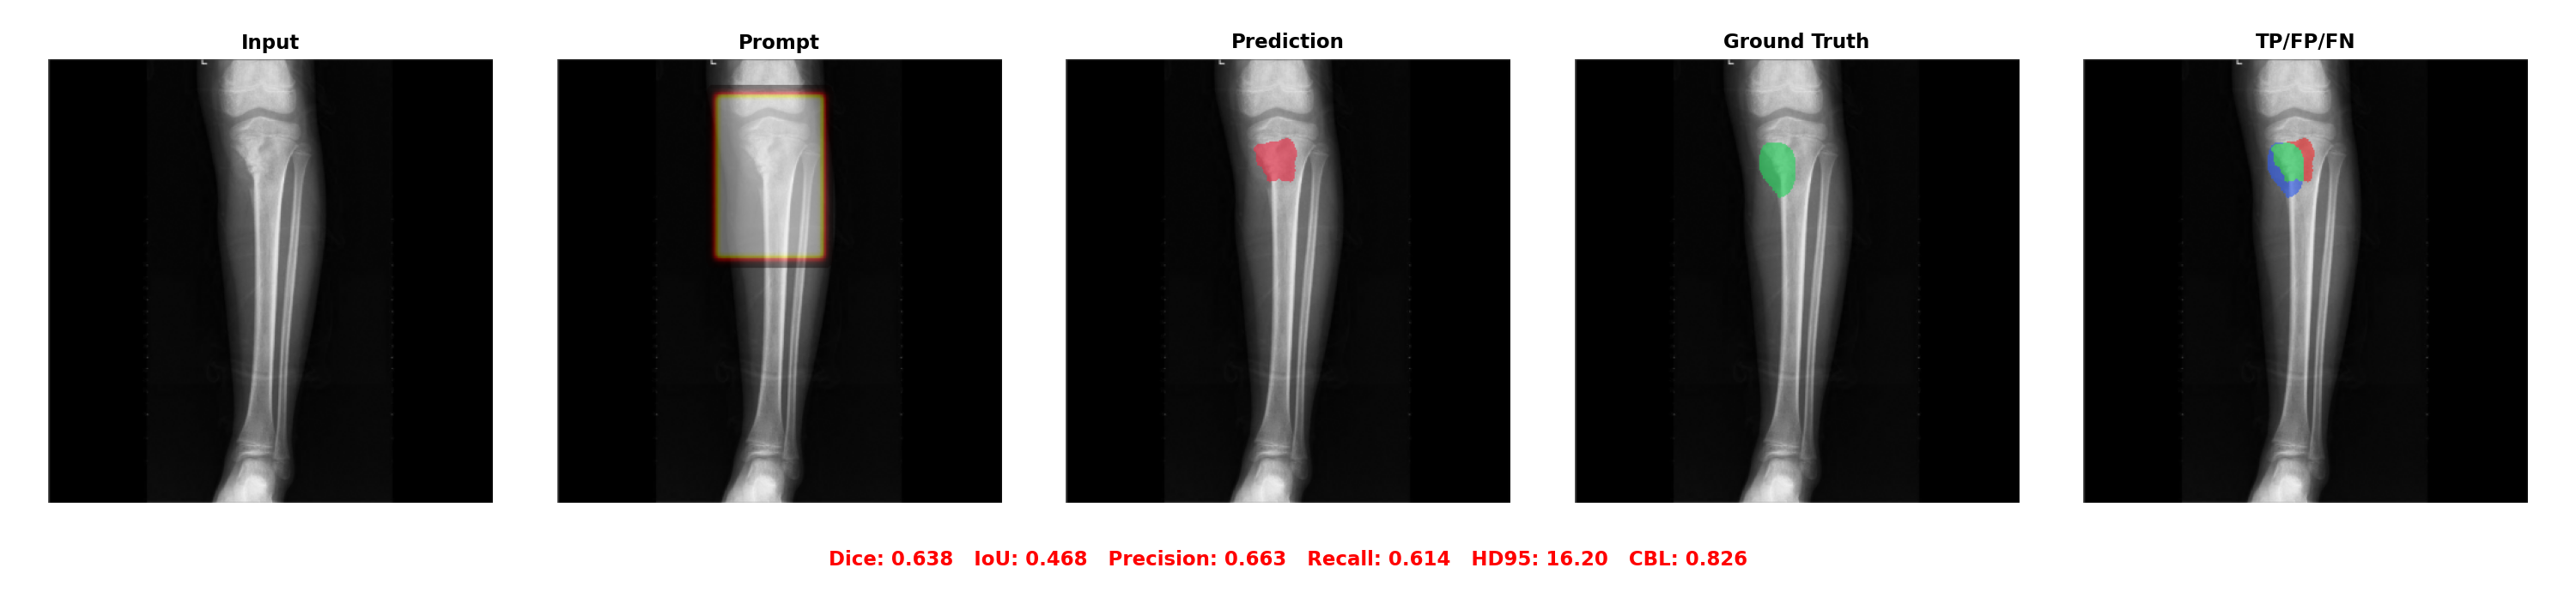

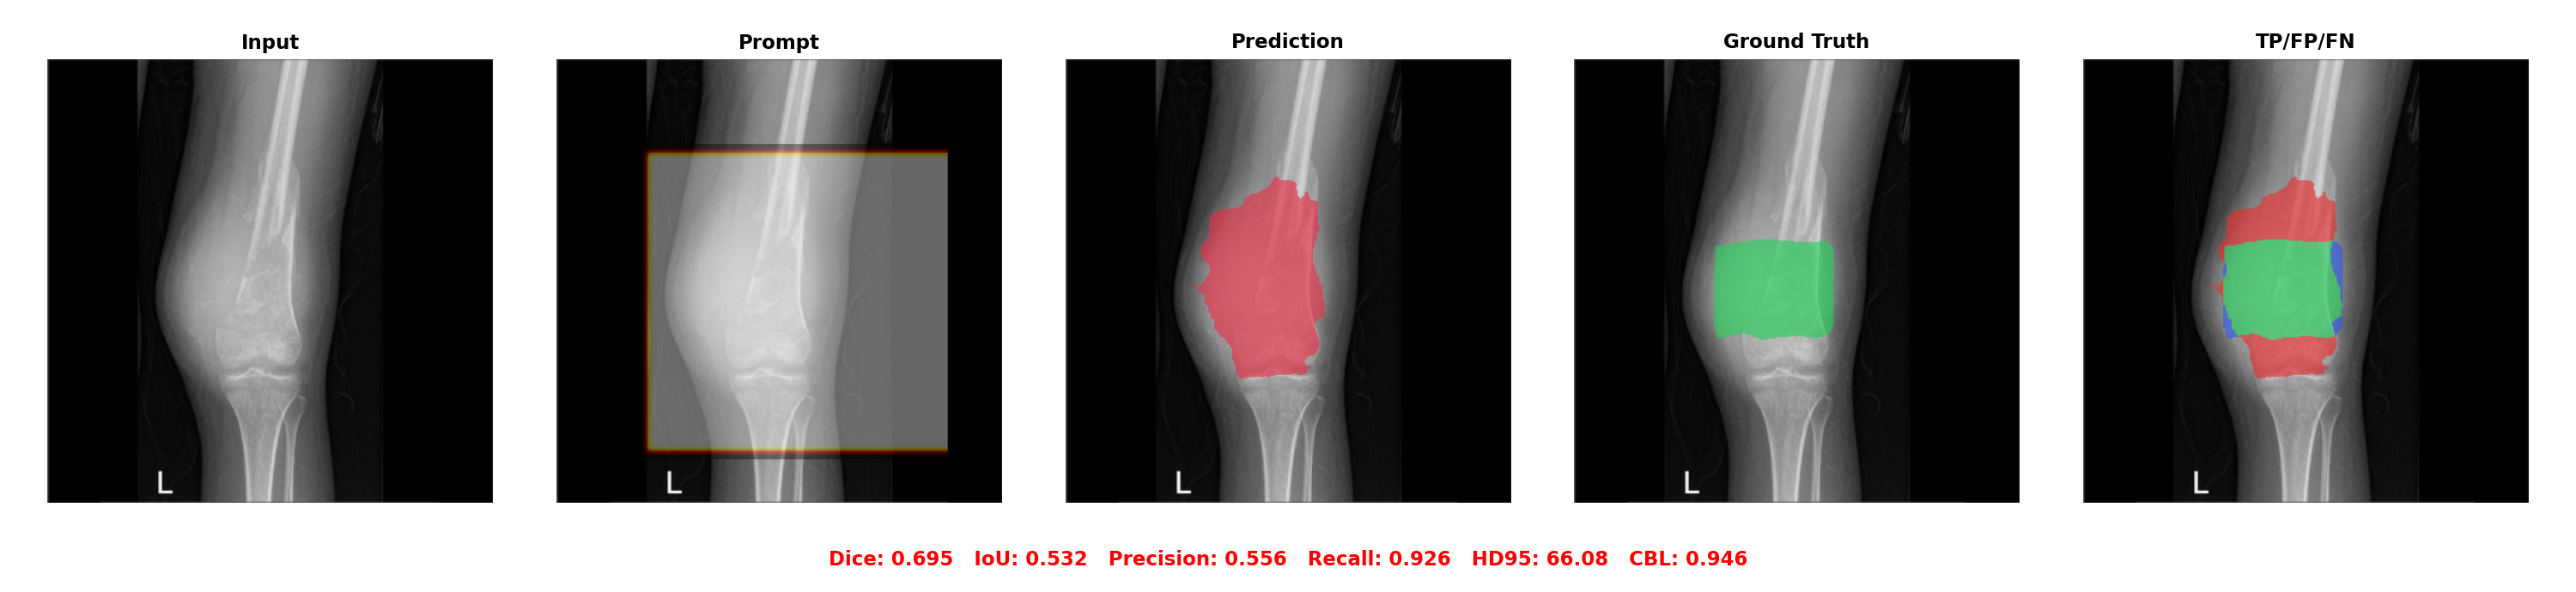

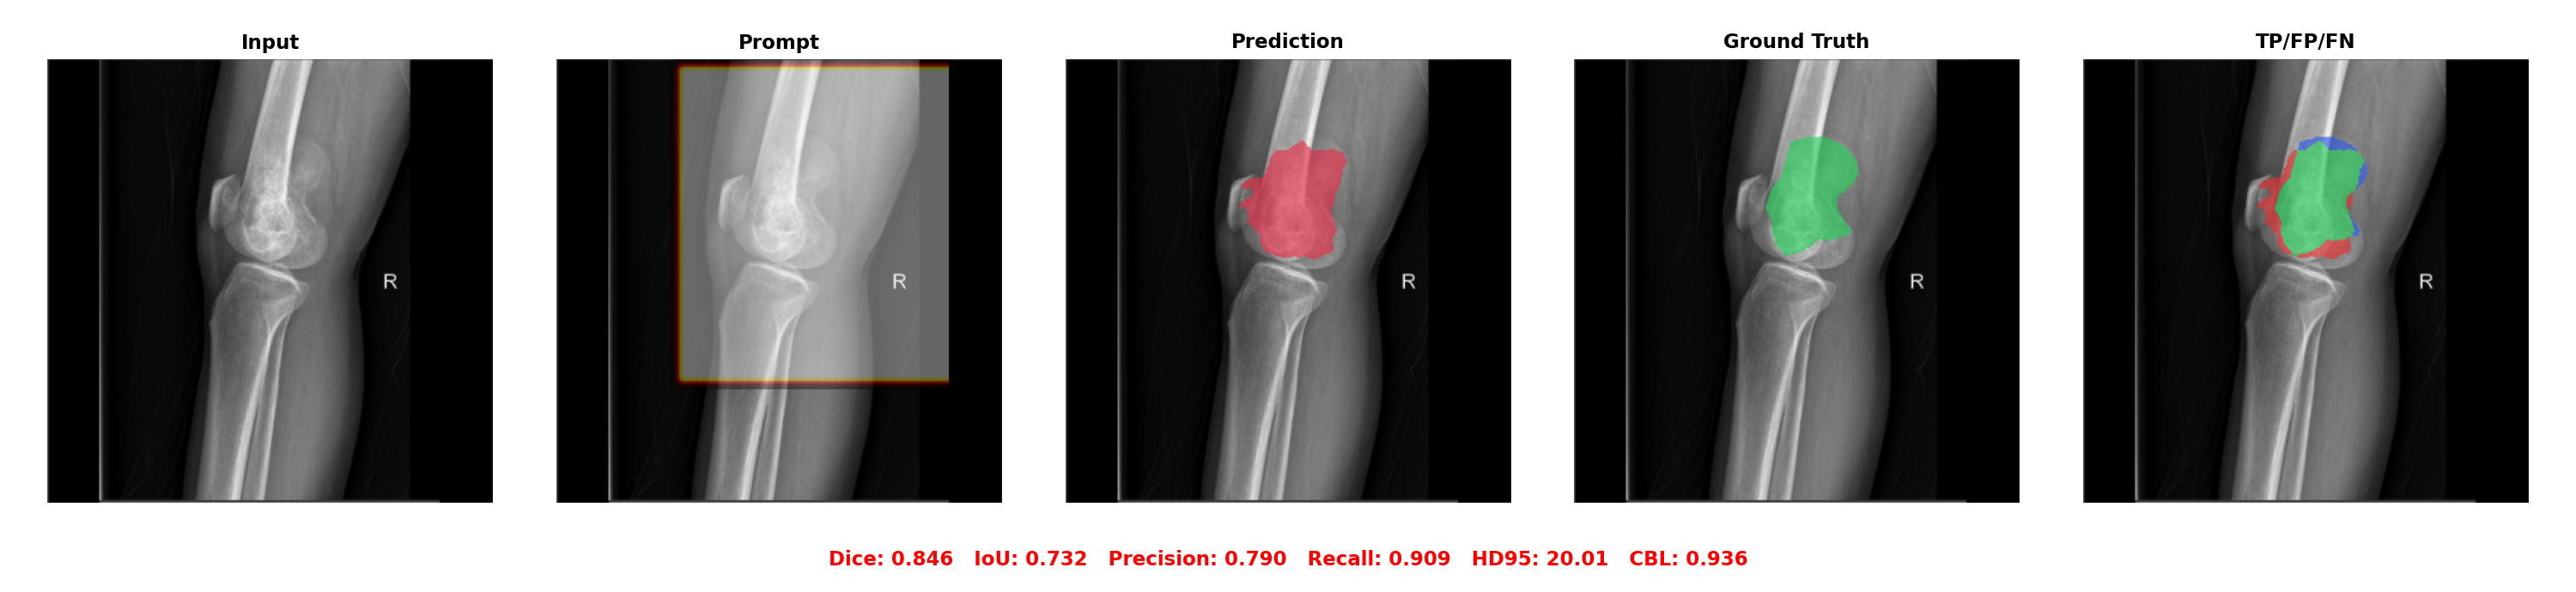

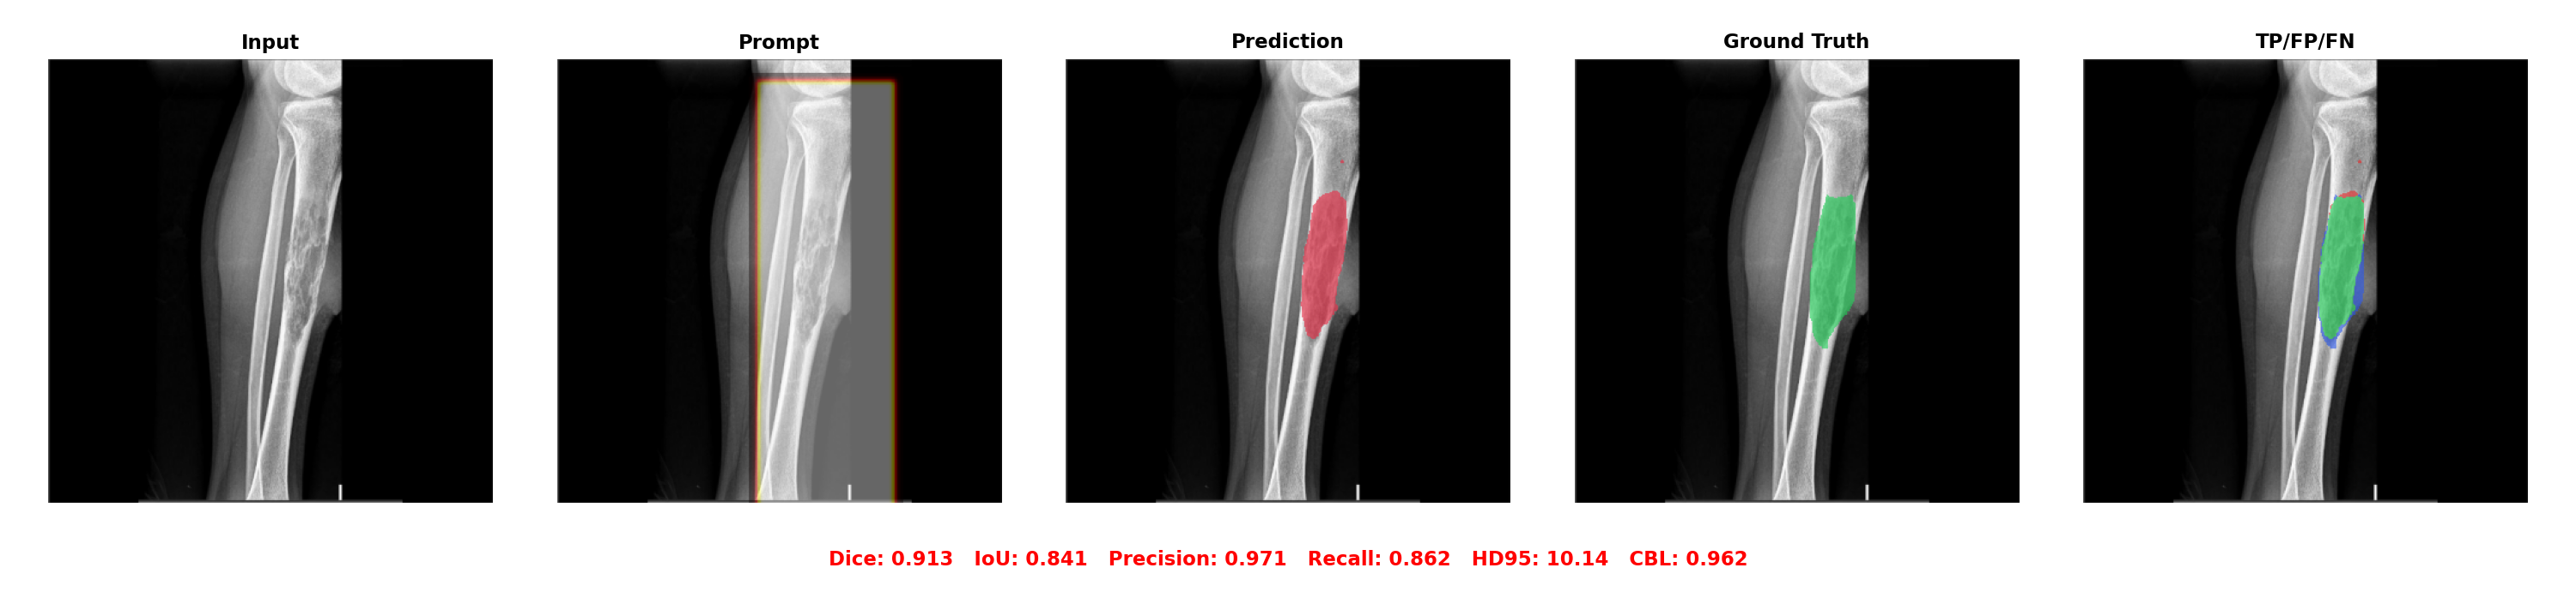

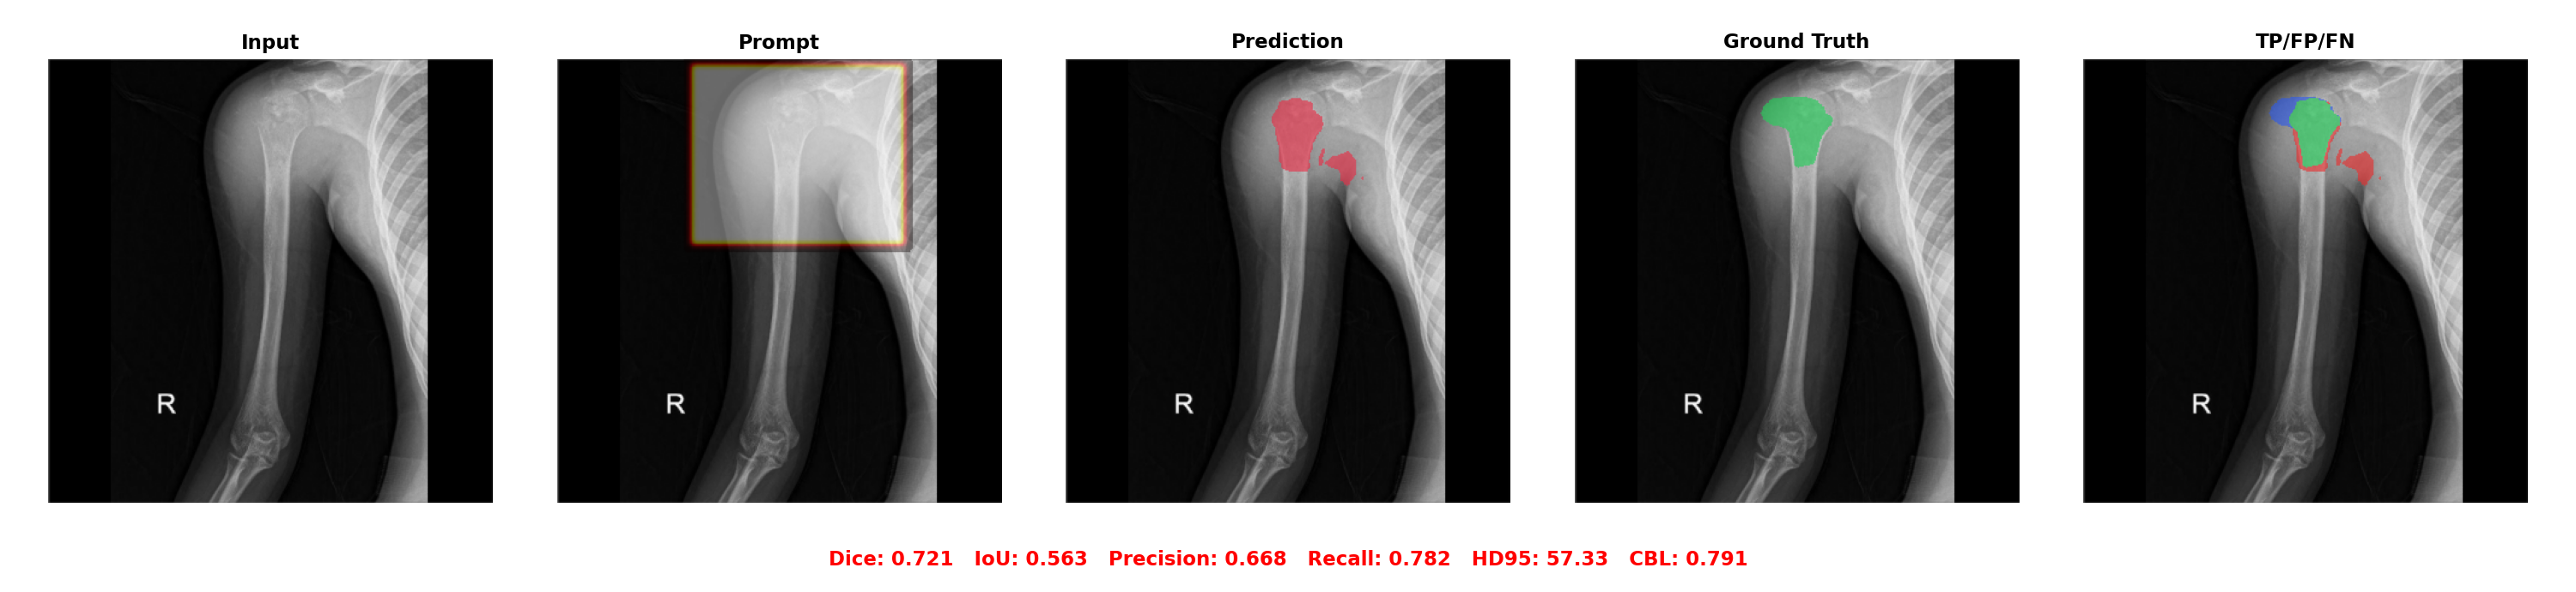

In [3]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
# @title
"""
test_exp_scenarios.py
=====================
Evaluation of two prompt scenarios: 100% center_zoom | 100% center_shift
(center_mixed x3/shift0.5, 80% shift / 20% zoom, QualityHead), alongside the
model's own no-GT confidence (CAD prompt-confidence gate + QualityHead), on
the full test set. Predictions are grouped and merged by image (elementwise
max over each image's polygons, matching test-pga-dataset-1234's and
test-pga-vs-attunet-variants-r512's per-image-merged convention) rather than
averaged per raw polygon-sample, so Dice/IoU/etc. here are directly
comparable to those notebooks' numbers. Saves a CSV under results/ and
visualizes 10 images per scenario (two separate figures). Small-lesion
subset analysis lives in its own dedicated test notebook
(test-subcat-small-r256 and test-subcat-small-r512), not duplicated here.

MODEL_PATH and LOSS_LABEL are derived automatically from USE_SIZE_TVERSKY/
USE_FOCAL_DICE (reused from the train cell above if this notebook is run
top-to-bottom in one session; default to the baseline, both 0, if this test
cell is run standalone in a fresh kernel).

Usage:
    python test_exp_scenarios.py
"""

import os
import sys
import cv2
import csv
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt

import importlib as _importlib
if 'dataset' in sys.modules: del sys.modules['dataset']
_importlib.invalidate_caches()
from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CONFIGURATION - edit here
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE           = 512
USE_ENCODER_PROMPT = True   # must match the training config above
USE_QUALITY_HEAD   = True   # must match the training config above

SCALE_FACTOR = 3.0
SHIFT_RATIO  = 0.5

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"

# Reuses USE_SIZE_TVERSKY/USE_FOCAL_DICE from the train cell above (falls
# back to the baseline, both 0, if this cell is run standalone).
_use_size_tversky = globals().get('USE_SIZE_TVERSKY', 0)
_use_focal_dice   = globals().get('USE_FOCAL_DICE', 0)
if _use_size_tversky:
    LOSS_LABEL  = "size_tversky"
    _loss_ckpt_suffix = "_sizetversky"
elif _use_focal_dice:
    LOSS_LABEL  = "focal_dice"
    _loss_ckpt_suffix = "_focaldice133"
else:
    LOSS_LABEL  = "baseline_dice"
    _loss_ckpt_suffix = ""
MODEL_PATH = f"checkpoints/pga_unet_center_mixed_x3_shift05_qhead{_loss_ckpt_suffix}_512_best.pth"


# =========================================================
# METRIC HELPERS & POST-PROCESSING
# =========================================================


def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2):
        return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0:
        return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 +
                      (xs.max() - xs.min()) ** 2) + 1e-6
    if pred_bin.sum() == 0:
        return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 +
                (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0:
        return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())

# =========================================================
# SINGLE-SCENARIO EVALUATION (image-level merge, + no-GT confidence)
# =========================================================
# Groups per-polygon predictions BY IMAGE first (elementwise max over GT
# masks and predicted probability maps for images with multiple lesions),
# then computes one Dice/IoU/etc. per image on the merged pair, matching
# test-pga-dataset-1234's and test-pga-vs-attunet-variants-r512's convention
# rather than averaging flatly over raw polygon-samples. QualityHead's
# per-sample prompt_conf/quality are averaged over an image's polygons (no
# precedent elsewhere for this signal, kept simple: plain mean).

def run_eval(model: torch.nn.Module, prompt_mode: str, **ds_kwargs) -> dict:
    ds = PromptSegmentationDataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
        **ds_kwargs,
    )
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)

    groups = OrderedDict()
    model.eval()
    with torch.no_grad():
        for i, (images, masks, prompts) in enumerate(loader):
            img_name = ds.all_samples[i][0]
            images_d, prompts_d = images.to(DEVICE), prompts.to(DEVICE)
            if USE_QUALITY_HEAD:
                logits, prompt_conf, quality = model(
                    images_d, prompts_d, return_confidence=True, return_quality=True)
                conf_val, qual_val = prompt_conf.item(), quality.item()
            else:
                logits = model(images_d, prompts_d)
                conf_val, qual_val = None, None
            prob_np = torch.sigmoid(logits)[0, 0].cpu().numpy()
            gt_np = masks[0, 0].numpy()
            prompt_np = prompts[0, 0].numpy()
            img_np = images[0, 0].numpy()

            if img_name not in groups:
                groups[img_name] = dict(img=img_np, gt_union=gt_np.copy(), prob_max=prob_np.copy(),
                                         prompts=[prompt_np], n_samples=1,
                                         conf_sum=(conf_val or 0.0), qual_sum=(qual_val or 0.0))
            else:
                g = groups[img_name]
                np.maximum(g['gt_union'], gt_np, out=g['gt_union'])
                np.maximum(g['prob_max'], prob_np, out=g['prob_max'])
                g['prompts'].append(prompt_np)
                g['n_samples'] += 1
                g['conf_sum'] += (conf_val or 0.0)
                g['qual_sum'] += (qual_val or 0.0)

    smooth = 1e-5
    all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []
    all_prompt_conf, all_quality = [], []
    img_recs = []
    for img_name in sorted(groups.keys()):
        g = groups[img_name]
        pm = (g['prob_max'] > 0.5).astype(np.float32)
        gm = g['gt_union']

        tp = (pm * gm).sum()
        fp = (pm * (1 - gm)).sum()
        fn = ((1 - pm) * gm).sum()

        dice = float((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
        iou  = float((tp + smooth) / (tp + fp + fn + smooth))
        pre  = float(tp / (tp + fp + smooth))
        rec  = float((tp + smooth) / (tp + fn + smooth))
        hd95 = calc_hd95(pm.astype(bool), gm.astype(bool))
        cbl  = calc_cbl(pm.astype(bool), gm.astype(bool))

        all_dice.append(dice); all_iou.append(iou); all_pre.append(pre); all_rec.append(rec)
        all_hd95.append(hd95)
        if cbl is not None:
            all_cbl.append(cbl)

        img_prompt_conf = (g['conf_sum'] / g['n_samples']) if USE_QUALITY_HEAD else None
        img_quality     = (g['qual_sum'] / g['n_samples']) if USE_QUALITY_HEAD else None
        if img_prompt_conf is not None:
            all_prompt_conf.append(img_prompt_conf)
            all_quality.append(img_quality)

        img_recs.append(dict(
            img_name=img_name, img=g['img'], gt=gm, prob=g['prob_max'], prompts=g['prompts'],
            n_samples=g['n_samples'], dice=dice, iou=iou, pre=pre, rec=rec,
            hd95=hd95, cbl=(cbl if cbl is not None else 0.0),
            prompt_conf=img_prompt_conf, quality=img_quality,
        ))

    return {
        'dice': np.mean(all_dice),
        'iou':  np.mean(all_iou),
        'pre':  np.mean(all_pre),
        'rec':  np.mean(all_rec),
        'hd95': np.mean(all_hd95),
        'hd95_normalized': np.mean(all_hd95) / (np.sqrt(2.0) * IMG_SIZE),
        'cbl':  np.mean(all_cbl) if all_cbl else 0.0,
        'prompt_conf': np.mean(all_prompt_conf) if all_prompt_conf else None,
        'quality':     np.mean(all_quality) if all_quality else None,
        'n_img':     len(img_recs),
        'n_samples': sum(r['n_samples'] for r in img_recs),
        'img_recs':  img_recs,
    }

# =========================================================
# TWO-SCENARIO EVALUATION
# =========================================================

def evaluate_all(model: torch.nn.Module) -> dict:
    enc_tag = 'ON' if USE_ENCODER_PROMPT else 'OFF'
    print("\n" + "=" * 72)
    print(f"  TWO-SCENARIO EVALUATION (image-level merged)  |  encoder_prompt = {enc_tag}  |  loss = {LOSS_LABEL}")
    print("=" * 72)

    scenarios = {
        '100% Zoom (center_zoom)':  dict(prompt_mode='center_zoom', scale_factor=SCALE_FACTOR),
        '100% Shift (center_shift)': dict(prompt_mode='center_shift', scale_factor=SCALE_FACTOR, shift_ratio=SHIFT_RATIO),
    }

    results = {}
    for name, kwargs in scenarios.items():
        results[name] = run_eval(model, **kwargs)
        r = results[name]
        print(f"  [{name}]  {r['n_img']} images ({r['n_samples']} polygons), completed.")

    header = (f"\n{'Scenario':<24} {'Dice↑':>7} {'IoU↑':>7} "
              f"{'Pre↑':>7} {'Rec↑':>7} {'HD95px↓':>8} {'HD95n↓':>8} {'CBL↑':>7} "
              f"{'PromptConf':>10} {'Quality':>8} {'N_img':>6} {'N_smp':>6}")
    print(header)
    print("-" * 113)
    for name, r in results.items():
        conf_str = f"{r['prompt_conf']:>10.4f}" if r['prompt_conf'] is not None else f"{'n/a':>10}"
        qual_str = f"{r['quality']:>8.4f}" if r['quality'] is not None else f"{'n/a':>8}"
        print(f"{name:<24} {r['dice']:>7.4f} {r['iou']:>7.4f} "
              f"{r['pre']:>7.4f} {r['rec']:>7.4f} "
              f"{r['hd95']:>8.2f} {r['hd95_normalized']:>8.6f} {r['cbl']:>7.4f} "
              f"{conf_str} {qual_str} {r['n_img']:>6} {r['n_samples']:>6}")
    return results

# =========================================================
# LOAD MODEL
# =========================================================
model = PGA_UNet(use_encoder_prompt=USE_ENCODER_PROMPT, use_quality_head=USE_QUALITY_HEAD).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"Model loaded from: {MODEL_PATH}  (loss = {LOSS_LABEL})")

# =========================================================
# TWO-SCENARIO EVALUATION: summary table
# =========================================================
results = evaluate_all(model)

# =========================================================
# SAVE CSV - one row per scenario, tagged by loss variant so multiple runs
# (baseline / size_tversky / focal_dice) can be compared side by side.
# Dice/IoU/etc. are image-level-merged averages (n_img images); n_samples
# is the raw polygon count, kept for reference only.
# =========================================================
os.makedirs('results', exist_ok=True)
csv_path = f'results/pga_{LOSS_LABEL}_{IMG_SIZE}.csv'
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['loss', 'scenario', 'dice', 'iou', 'pre', 'rec', 'hd95', 'hd95_normalized', 'cbl',
                     'prompt_conf', 'quality', 'n_img', 'n_samples'])
    for name, r in results.items():
        writer.writerow([LOSS_LABEL, name,
                         f"{r['dice']:.4f}", f"{r['iou']:.4f}", f"{r['pre']:.4f}", f"{r['rec']:.4f}",
                         f"{r['hd95']:.4f}", f"{r['hd95_normalized']:.6f}", f"{r['cbl']:.4f}",
                         f"{r['prompt_conf']:.4f}" if r['prompt_conf'] is not None else '',
                         f"{r['quality']:.4f}" if r['quality'] is not None else '',
                         r['n_img'], r['n_samples']])
print(f"\nSaved CSV: {csv_path}")

# =========================================================
# VISUALIZATION - 10 images per scenario, two separate figures, image-level
# merged (matching test-pga-dataset-1234's convention), with no-GT
# confidence (CAD prompt-confidence + QualityHead) shown per image
# =========================================================
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

N_SHOW = 10
TRAIN_SHARED_STEMS = select_shared_stems(
    results['100% Zoom (center_zoom)']['img_recs'], n_multi=5, n_single=5)

def visualize_scenario(scenario_name, title_suffix):
    img_recs = records_for_stems(
        results[scenario_name]['img_recs'], TRAIN_SHARED_STEMS,
        context=f'{scenario_name} qualitative records')
    n_show = len(img_recs)

    fig, axes = plt.subplots(n_show, 5, figsize=(20, 4 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f"PGA-UNet Train ({IMG_SIZE}, loss={LOSS_LABEL}) - Visualization "
                 f"({title_suffix}, image-level merged, first {n_show} images)",
                 fontsize=13, y=1.001)
    col_titles = ["Input image", "Image + prompts", "Prediction (merged)", "Ground truth", "TP/FP/FN"]
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=10, fontweight="bold")

    for count, rec in enumerate(img_recs):
        img_np  = rec['img'] * 0.5 + 0.5
        gt_np   = (rec['gt'] > 0.5).astype(float)
        pred_np = (rec['prob'] > 0.5).astype(float)
        prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0)

        row = axes[count]
        bg  = np.stack([img_np]*3, axis=-1)

        conf_label = (f" | Conf={rec['prompt_conf']:.2f} Qual={rec['quality']:.2f}"
                      if rec['prompt_conf'] is not None else "")
        row[0].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        row[0].set_ylabel(f"#{count+1} [{rec['n_samples']} poly]\nDice={rec['dice']:.3f}{conf_label}", fontsize=8)

        row[1].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap="hot", alpha=0.4, vmin=0, vmax=1)
        row[1].set_title(rec['img_name'], fontsize=6, pad=2)

        pr_ov = bg.copy()
        pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
        pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.2,  0, 1)
        row[2].imshow(pr_ov)
        row[2].set_title(f"Dice={rec['dice']:.3f} IoU={rec['iou']:.3f}", fontsize=7, color="darkred", pad=2)

        gt_ov = bg.copy()
        gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
        gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.2,  0, 1)
        row[3].imshow(gt_ov)

        inter = bg.copy()
        inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np*0.9,     0, 1)
        inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)*1.0, 0, 1)
        inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np*1.0, 0, 1)
        row[4].imshow(inter)
        row[4].set_title(f"Pre={rec['pre']:.3f} Rec={rec['rec']:.3f}", fontsize=7, color="saddlebrown", pad=2)

        for ax in row:
            ax.axis("off")
            ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

    fig.legend(handles=[Patch(facecolor="green",label="TP"),Patch(facecolor="red",label="FP"),Patch(facecolor="blue",label="FN")],
               loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.01))
    plt.tight_layout()
    export_qualitative_rows(fig, axes, img_recs)
    plt.close(fig)

visualize_scenario('100% Zoom (center_zoom)', 'center_zoom')
visualize_scenario('100% Shift (center_shift)', 'center_shift')
